# Sleep Health & Lifestyle Dataset

**CRISP-DM — Data Understanding**

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# Torna src/ importável independente de onde o kernel foi iniciado
ROOT = Path('../').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy import stats

from src.constants import DATA_DIR, DATA_FILE_NAME
from src.data_downloader import DataDownloader
from src.logger import get_logger, setup_logger

import warnings
from src.constants import ALPHA

warnings.filterwarnings("ignore", category=FutureWarning)



# --- Configurações gerais ---
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# --- Estilo dos gráficos ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [3]:
setup_logger(level='INFO')
log = get_logger(__name__)

In [4]:
data_path = DATA_DIR / DATA_FILE_NAME

if data_path.exists():
    log.info('Carregando dados do cache local')
    df = pd.read_csv(data_path)
else:
    log.info('Arquivo nao encontrado - iniciando download')
    df = DataDownloader().download()

07:06:47 | INFO     | __main__:4 - Carregando dados do cache local


# Dataset: Sleep Health and Lifestyle

## About this Dataset

### Columns Description

| Column | Description |
|--------|-------------|
| **Person ID** | An identifier for each individual |
| **Gender** | The gender of the person (Male/Female) |
| **Age** | The age of the person in years |
| **Occupation** | The occupation or profession of the person |
| **Sleep Duration (hours)** | The number of hours the person sleeps per day |
| **Quality of Sleep (scale: 1-10)** | A subjective rating of the quality of sleep, ranging from 1 to 10 |
| **Physical Activity Level (minutes/day)** | The number of minutes the person engages in physical activity daily |
| **Stress Level (scale: 1-10)** | A subjective rating of the stress level experienced by the person, ranging from 1 to 10 |
| **BMI Category** | The BMI category of the person (e.g., Underweight, Normal, Overweight) |
| **Blood Pressure (systolic/diastolic)** | The blood pressure measurement, indicated as systolic pressure over diastolic pressure |
| **Heart Rate (bpm)** | The resting heart rate of the person in beats per minute |
| **Daily Steps** | The number of steps the person takes per day |
| **Sleep Disorder** | The presence or absence of a sleep disorder (None, Insomnia, Sleep Apnea) |

---

> **Source:** [Kaggle - Sleep Health and Lifestyle Dataset](https://www.kaggle.com/)

## Details about Sleep Disorder Column

- `None`: The individual does not exhibit any specific sleep disorder.
- `Insomnia`: The individual experiences difficulty falling asleep or staying asleep, leading to inadequate or poor-quality sleep.
- `Sleep Apnea`: The individual suffers from pauses in breathing during sleep, resulting in disrupted sleep patterns and potential health risks.

In [22]:
print(f'Shape: {df.shape}')
df.head()

Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.10,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [24]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00


## Data Description (Audit of dataset)
___

In [25]:
def describe_dataframe(df: pd.DataFrame) -> pd.DataFrame.style:
    """Gera um resumo estrutural do DataFrame com estilo visual.

    Retorna uma tabela estilizada com tipo, contagem de valores não-nulos
    e percentual de dados faltantes por coluna.

    Args:
        df: DataFrame a ser descrito.

    Returns:
        pd.DataFrame.style: Tabela estilizada com header destacado.
    """
    # Corrige Sleep Disorder: 'None' string não é dado faltante
    df = df.copy()
    df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "non_null_count": df.notna().sum(),
        "null_count": df.isna().sum(),
        "missing_pct": (df.isna().sum() / len(df) * 100).round(2),
    }).sort_values("missing_pct", ascending=False)

    return (
        summary.style
        .set_table_styles([{
            "selector": "thead th",
            "props": [
                ("background-color", "#2c7bb6"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("font-size", "13px"),
                ("padding", "8px"),
            ]
        }])
        .format({"missing_pct": "{:.2f}%"})
    )

In [26]:
describe_dataframe(df)

,dtype,non_null_count,null_count,missing_pct
Person ID,int64,374,0,0.00%
Gender,str,374,0,0.00%
Age,int64,374,0,0.00%
Occupation,str,374,0,0.00%
Sleep Duration,float64,374,0,0.00%
Quality of Sleep,int64,374,0,0.00%
Physical Activity Level,int64,374,0,0.00%
Stress Level,int64,374,0,0.00%
BMI Category,str,374,0,0.00%
Blood Pressure,str,374,0,0.00%


## Observação: Coluna Sleep Disorder

Os valores faltantes nesta coluna **não representam ausência de dado**.
O valor `None` indica que o indivíduo não possui distúrbio do sono diagnosticado.

### Categorias:
- `None`: sem distúrbio do sono
- `Insomnia`: dificuldade em adormecer ou manter o sono
- `Sleep Apnea`: pausas na respiração durante o sono

In [27]:
def inspect_dtypes(df: pd.DataFrame) -> dict[str, list[str]]:
    """Separa colunas por dtype detectado pelo pandas.

    Args:
        df: DataFrame a ser inspecionado.

    Returns:
        dict com chaves 'numeric' e 'categorical'.
    """
    numeric = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical = df.select_dtypes(include=["object", "str"]).columns.tolist()

    return {"numeric": numeric, "categorical": categorical}


# Uso
types = inspect_dtypes(df)
print("Numeric:    ", types["numeric"])
print("Categorical:", types["categorical"])

Numeric:     ['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
Categorical: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']


## Classificação das Variáveis

### Variáveis Numéricas

#### Contínuas
| Coluna | Descrição | Justificativa |
|--------|-----------|---------------|
| **Sleep Duration** | Horas de sono por dia | Valores decimais em intervalo contínuo (ex: 7.5h) |
| **Blood Pressure** | Pressão sistólica/diastólica | Contínua, mas armazenada como string — requer parsing |

#### Inteiras
| Coluna | Descrição | Justificativa |
|--------|-----------|---------------|
| **Age** | Idade em anos | Anos completos, sem decimais |
| **Physical Activity Level** | Minutos de atividade/dia | Contagem inteira de minutos |
| **Heart Rate** | Batimentos por minuto | Contagem inteira de bpm |
| **Daily Steps** | Passos por dia | Contagem inteira de passos |

> **Person ID**: detectado como numérico pelo pandas, mas é um **identificador** — não entra em nenhuma análise estatística.

---

### Variáveis Categóricas

#### Nominais
| Coluna | Descrição | Justificativa |
|--------|-----------|---------------|
| **Gender** | Masculino/Feminino | Categorias sem ordem natural |
| **Occupation** | Profissão | Categorias sem hierarquia |
| **Sleep Disorder** | None/Insomnia/Sleep Apnea | Categorias sem ordem natural |

#### Ordinais
| Coluna | Descrição | Justificativa |
|--------|-----------|---------------|
| **Quality of Sleep** | Escala 1-10 | Ordem importa, mas intervalos não são uniformes |
| **Stress Level** | Escala 1-10 | Ordem importa, mas intervalos não são uniformes |
| **BMI Category** | Underweight/Normal/Overweight | Categorias com ordem implícita de risco clínico |

---

> **Nota metodológica:** o `dtype` detectado pelo pandas é o ponto de partida técnico.
> A classificação estatística final exige interpretação do domínio — 
> `Quality of Sleep` e `Stress Level` são `int64` para o pandas, mas ordinais na prática.

# Variable Classification

## Numeric Variables

### Continuous
| Column | Description | Justification |
|--------|-------------|---------------|
| **Sleep Duration** | Daily sleep hours | Decimal values in a continuous range (e.g. 7.5h) |
| **Blood Pressure** | Systolic/diastolic pressure | Continuous measurement, stored as string — requires parsing |

### Integer
| Column | Description | Justification |
|--------|-------------|---------------|
| **Age** | Age in years | Whole years, no decimals |
| **Physical Activity Level** | Activity minutes per day | Integer count of minutes |
| **Heart Rate** | Beats per minute | Integer count of bpm |
| **Daily Steps** | Steps per day | Integer count of steps |

> **Person ID**: detected as numeric by pandas, but it is an **identifier** — excluded from all statistical analysis.

---

## Categorical Variables

### Nominal
| Column | Description | Justification |
|--------|-------------|---------------|
| **Gender** | Male/Female | Categories with no natural order |
| **Occupation** | Job title | Categories with no hierarchy |
| **Sleep Disorder** | None/Insomnia/Sleep Apnea | Categories with no natural order |

### Ordinal
| Column | Description | Justification |
|--------|-------------|---------------|
| **Quality of Sleep** | Scale 1–10 | Order matters, but intervals are not uniform |
| **Stress Level** | Scale 1–10 | Order matters, but intervals are not uniform |
| **BMI Category** | Underweight/Normal/Overweight/Obese | Implicit clinical risk order |

---

## Methodological Note

The pandas `dtype` is the technical starting point, but the **final statistical classification requires domain interpretation**:

- `Quality of Sleep` and `Stress Level` are `int64` for pandas, but **ordinal** in practice — the scale implies ranking without uniform intervals.
- `Gender` is classified as **nominal** because there is no inherent order between categories. Nominal variables are defined by the absence of any natural ranking.
- `BMI Category` is classified as **ordinal** because the categories follow an implicit clinical risk progression: Underweight → Normal → Overweight → Obese.

## Nota Metodológica — População, Amostra e Escopo da Análise

### População vs Amostra

**População** é o conjunto completo de todos os indivíduos sobre os quais desejamos
tirar conclusões — neste contexto: *todos os adultos suscetíveis a distúrbios do sono.*

**Amostra** é o subconjunto coletado para representar essa população.
Este dataset contém **374 indivíduos**, e é sobre eles que colocamos a lupa analítica.

---

### Escopo deste Projeto — Estatística Descritiva

Este projeto se limita à **estatística descritiva** — descrevemos quem são
as pessoas da amostra, sem generalizações para a população maior.

| Tipo de Análise | O que faz | Aplicável aqui? |
|-----------------|-----------|-----------------|
| **Descritiva** | Descreve a amostra | ✅ Sim |
| **Inferencial** | Generaliza para a população | ❌ Fora do escopo |

---

### Desvio Padrão — Amostra vs População

Um detalhe técnico importante que aparece em provas:

| | Fórmula | Quando usar |
|--|---------|-------------|
| **Populacional** | divide por **n** | quando temos toda a população |
| **Amostral** | divide por **n-1** | quando temos uma amostra |

> O `df.std()` do pandas usa **n-1** por padrão — ou seja, trata os dados como amostra.
> Para usar o desvio padrão populacional: `df.std(ddof=0)`

---

### Pergunta-guia do Ato 1

> *"A amostra é equilibrada, ou apresenta viés que pode influenciar as conclusões?"*

Analisaremos:
- **Perfil demográfico**: Gênero e Idade
- **Perfil profissional**: Ocupação
- **Perfil de saúde**: BMI Category e Sleep Disorder

* Gênero ->nominal->frequência e proporção

* Idade -> inteira -> medidas de centro, dispersão e distribuição

```python
# ── Palettes / orders ─────────────────────────────────────────────────────────

# Paleta de cores para variáveis categóricas — usada em todos os gráficos
# para manter consistência visual ao longo da análise

_PAL_GENDER: dict[str, str] = {
    "Male": "#4c72b0",
    "Female": "#dd8452"
}

_PAL_DISORDER: dict[str, str] = {
    "None": "#55a868",        # verde — sem distúrbio
    "Insomnia": "#c44e52",    # vermelho — insônia
    "Sleep Apnea": "#8172b2"  # roxo — apneia
}

_PAL_BMI: dict[str, str] = {
    "Normal": "#55a868",      # verde — peso normal
    "Overweight": "#f5a623",  # amarelo — sobrepeso
    "Obese": "#c44e52"        # vermelho — obeso
}

# Ordens explícitas para garantir sequência correta nos gráficos
# BMI e Sleep Disorder têm ordem semântica — do menos para o mais grave
_BMI_ORDER: list[str] = ["Normal", "Overweight", "Obese"]
_DIS_ORDER: list[str] = ["None", "Insomnia", "Sleep Apnea"]


# ── Internal helpers ──────────────────────────────────────────────────────────

def _prep(df: pd.DataFrame) -> pd.DataFrame:
    """Padroniza uma cópia do DataFrame antes de qualquer análise.

    Operações realizadas:
    - Preenche NaN em 'Sleep Disorder' com 'None' — ausência de distúrbio,
      não dado faltante.
    - Normaliza 'BMI Category': substitui 'Normal Weight' por 'Normal'
      para consistência com _PAL_BMI e _BMI_ORDER.

    Args:
        df: DataFrame bruto carregado pelo DataDownloader.

    Returns:
        pd.DataFrame: Cópia padronizada, sem modificar o original.
    """
    d = df.copy()
    d["Sleep Disorder"] = d["Sleep Disorder"].fillna("None")
    d["BMI Category"] = d["BMI Category"].replace("Normal Weight", "Normal")
    return d


def _fmt_p(p: float) -> str:
    """Formata o p-value para exibição padronizada.

    Exibe 4 casas decimais quando p >= 0.0001,
    ou 'p < 0.0001' para valores muito pequenos.

    Args:
        p: p-value calculado por um teste estatístico.

    Returns:
        str: p-value formatado para uso em títulos ou anotações de gráficos.

    Examples:
        >>> _fmt_p(0.0352)
        'p = 0.0352'
        >>> _fmt_p(0.000001)
        'p < 0.0001'
    """
    return f"p = {p:.4f}" if p >= 0.0001 else "p < 0.0001"


def _section(title: str) -> None:
    """Imprime um separador visual de seção no output do notebook.

    Útil para organizar o output de células longas que executam
    múltiplas análises em sequência.

    Args:
        title: Título da seção a ser exibido.

    Examples:
        >>> _section("Ato 1 — Perfil Demográfico")
        ══════════════════════════════════════════════════════════════
          Ato 1 — Perfil Demográfico
        ══════════════════════════════════════════════════════════════
    """
    width = 62
    print("\n" + "=" * width)
    print(f"  {title}")
    print("=" * width)
```

Três observações sobre o código:

**`_prep`** é a função mais importante do conjunto — ela garante que toda análise parte dos mesmos dados padronizados. O underscore no início indica que são funções internas, não fazem parte da API pública do módulo.

**`_fmt_p`** vai ser muito útil nos Atos 3 e 4 quando começarmos correlações e comparações entre grupos — p-value aparece em quase todo teste estatístico.

**`_section`** é simples mas faz diferença no output do notebook quando você roda várias análises numa célula só.

In [28]:
# ── Palettes / orders ─────────────────────────────────────────────────────────
_PAL_GENDER   = {"Male": "#4c72b0", "Female": "#dd8452"}
_PAL_DISORDER = {"None": "#55a868", "Insomnia": "#c44e52", "Sleep Apnea": "#8172b2"}
_PAL_BMI      = {"Normal": "#55a868", "Overweight": "#f5a623", "Obese": "#c44e52"}
_BMI_ORDER    = ["Normal", "Overweight", "Obese"]
_DIS_ORDER    = ["None", "Insomnia", "Sleep Apnea"]

# ── Internal helpers ──────────────────────────────────────────────────────────

def _prep(df: pd.DataFrame) -> pd.DataFrame:
    """Standardise a copy of the DataFrame before any analysis."""
    d = df.copy()
    d["Sleep Disorder"] = d["Sleep Disorder"].fillna("None")
    d["BMI Category"] = d["BMI Category"].replace("Normal Weight", "Normal")
    return d


def _fmt_p(p: float) -> str:
    return f"p = {p:.4f}" if p >= 0.0001 else "p < 0.0001"


def _section(title: str) -> None:
    width = 62
    print("\n" + "=" * width)
    print(f"  {title}")
    print("=" * width)


def _pairwise_mw(
    data: pd.DataFrame,
    group_col: str,
    value_col: str,
    groups: list[str] | None = None,
) -> pd.DataFrame:
    """Realiza testes Mann-Whitney U pareados com correção de Bonferroni.

    Compara todas as combinações de pares de grupos usando o teste não-paramétrico
    de Mann-Whitney U (bicaudal). Os p-valores são ajustados pela correção de
    Bonferroni para controlar a taxa de erro familial (FWER). Pares com menos
    de 3 observações em qualquer grupo são ignorados.

    Args:
        data: DataFrame contendo os dados de entrada.
        group_col: Nome da coluna que identifica os grupos categóricos.
        value_col: Nome da coluna numérica a ser comparada entre os grupos.
        groups: Lista de grupos a incluir nas comparações. Se ``None``,
            todos os valores únicos (não-nulos) de ``group_col`` são usados.

    Returns:
        DataFrame com uma linha por par comparado, contendo as colunas:

        - **group1** (*str*): Primeiro grupo do par.
        - **group2** (*str*): Segundo grupo do par.
        - **U** (*float*): Estatística U de Mann-Whitney.
        - **p_raw** (*float*): P-valor bruto (sem correção), arredondado a 4 casas.
        - **p_bonf** (*float*): P-valor ajustado por Bonferroni, arredondado a 4 casas.
        - **sig** (*bool*): ``True`` se ``p_bonf < ALPHA``.

    Example:
        >>> import pandas as pd
        >>> df = pd.DataFrame({
        ...     "grupo": ["A"] * 20 + ["B"] * 20 + ["C"] * 20,
        ...     "valor": list(range(20)) + list(range(10, 30)) + list(range(5, 25)),
        ... })
        >>> resultado = _pairwise_mw(df, group_col="grupo", value_col="valor")
        >>> resultado[["group1", "group2", "p_bonf", "sig"]]
          group1 group2  p_bonf    sig
        0      A      B  0.0261   True
        1      A      C  0.5127  False
        2      B      C  0.1140  False
    """
    if groups is None:
        groups = data[group_col].dropna().unique().tolist()
    pairs = list(combinations(groups, 2))
    n = len(pairs)
    rows = []
    for g1, g2 in pairs:
        x1 = data.loc[data[group_col] == g1, value_col].dropna()
        x2 = data.loc[data[group_col] == g2, value_col].dropna()
        if len(x1) < 3 or len(x2) < 3:
            continue
        u_stat, p_raw = stats.mannwhitneyu(x1, x2, alternative="two-sided")
        p_adj = min(p_raw * n, 1.0)
        rows.append(
            {
                "group1": g1,
                "group2": g2,
                "U": round(u_stat, 2),
                "p_raw": round(p_raw, 4),
                "p_bonf": round(p_adj, 4),
                "sig": p_adj < ALPHA,
            }
        )
    return pd.DataFrame(rows)


In [29]:
def frequency_table(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """Calcula frequência e proporção de uma variável nominal.

    Args:
        df: DataFrame padronizado.
        col: Nome da coluna categórica.

    Returns:
        pd.DataFrame com colunas [col, count, pct].
    """
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, "count"]
    counts["pct"] = (counts["count"] / len(df) * 100).round(2)
    return counts


def describe_numeric(df: pd.DataFrame, col: str) -> pd.Series:
    """Calcula medidas de centro, dispersão e forma para variável numérica.

    Args:
        df: DataFrame padronizado.
        col: Nome da coluna numérica.

    Returns:
        pd.Series com mean, median, mode, std, iqr, range, cv e skew_direction.
    """
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    mean, median = s.mean(), s.median()

    return pd.Series({
        "mean":           round(mean, 2),
        "median":         round(median, 2),
        "mode":           s.mode()[0],
        "std":            round(s.std(), 2),
        "iqr":            round(q3 - q1, 2),
        "range":          s.max() - s.min(),
        "cv":             round(s.std() / mean * 100, 2),
        "skew_direction": "positive" if mean > median else "negative" if mean < median else "symmetric",
    })


def age_by_gender(df: pd.DataFrame) -> pd.DataFrame:
    """Agrupa estatísticas de idade por gênero.

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com estatísticas de Age agrupadas por Gender.
    """
    return (
        df.groupby("Gender")["Age"]
        .agg(count="count", mean="mean", median="median",
             std="std", min="min", max="max")
        .round(2)
    )

In [30]:
def plot_gender(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Countplot de distribuição por gênero."""
    sns.countplot(
        data=df, x="Gender",
        palette=_PAL_GENDER,
        order=list(_PAL_GENDER.keys()),
        ax=ax
    )
    ax.set_title("Distribuição por Gênero")
    ax.set_xlabel("Gênero")
    ax.set_ylabel("Contagem")


def plot_age(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Histograma com KDE para distribuição de idade."""
    sns.histplot(data=df, x="Age", kde=True, color="#4c72b0", ax=ax)
    ax.set_title("Distribuição de Idade")
    ax.set_xlabel("Idade (anos)")
    ax.set_ylabel("Contagem")


def plot_occupation(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Countplot horizontal de distribuição por ocupação."""
    sns.countplot(
        data=df, y="Occupation",
        order=df["Occupation"].value_counts().index,
        palette="muted", ax=ax
    )
    ax.set_title("Distribuição por Ocupação")
    ax.set_xlabel("Contagem")
    ax.set_ylabel("Ocupação")

In [31]:
def act1_demographic_profile(df: pd.DataFrame) -> None:
    """Ato 1 — Quem são essas pessoas?

    Orquestra as análises univariadas do perfil demográfico da amostra.

    Args:
        df: DataFrame bruto.
    """
    d = _prep(df)
    _section("Ato 1 — Perfil Demográfico: Quem são essas pessoas?")

    print("\n📊 Gênero — Frequência e Proporção")
    print(frequency_table(d, "Gender").to_string(index=False))

    print("\n📊 Idade — Medidas de Centro e Dispersão")
    print(describe_numeric(d, "Age"))

    print("\n📊 Ocupação — Frequência e Proporção")
    print(frequency_table(d, "Occupation").to_string(index=False))

    print("\n📊 Gênero x Idade — Distribuição por Grupo")
    print(age_by_gender(d))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Ato 1 — Perfil Demográfico da Amostra", fontsize=15, y=1.02)

    plot_gender(d, axes[0])
    plot_age(d, axes[1])
    plot_occupation(d, axes[2])

    plt.tight_layout()
    plt.show()


  Ato 1 — Perfil Demográfico: Quem são essas pessoas?

📊 Gênero — Frequência e Proporção
Gender  count   pct
  Male    189 50.53
Female    185 49.47

📊 Idade — Medidas de Centro e Dispersão
mean                 42.18
median               43.00
mode                    43
std                   8.67
iqr                  14.75
range                   32
cv                   20.56
skew_direction    negative
dtype: object

📊 Ocupação — Frequência e Proporção
          Occupation  count   pct
               Nurse     73 19.52
              Doctor     71 18.98
            Engineer     63 16.84
              Lawyer     47 12.57
             Teacher     40 10.70
          Accountant     37  9.89
         Salesperson     32  8.56
   Software Engineer      4  1.07
           Scientist      4  1.07
Sales Representative      2  0.53
             Manager      1  0.27

📊 Gênero x Idade — Distribuição por Grupo
        count  mean  median  std  min  max
Gender                                    
Femal

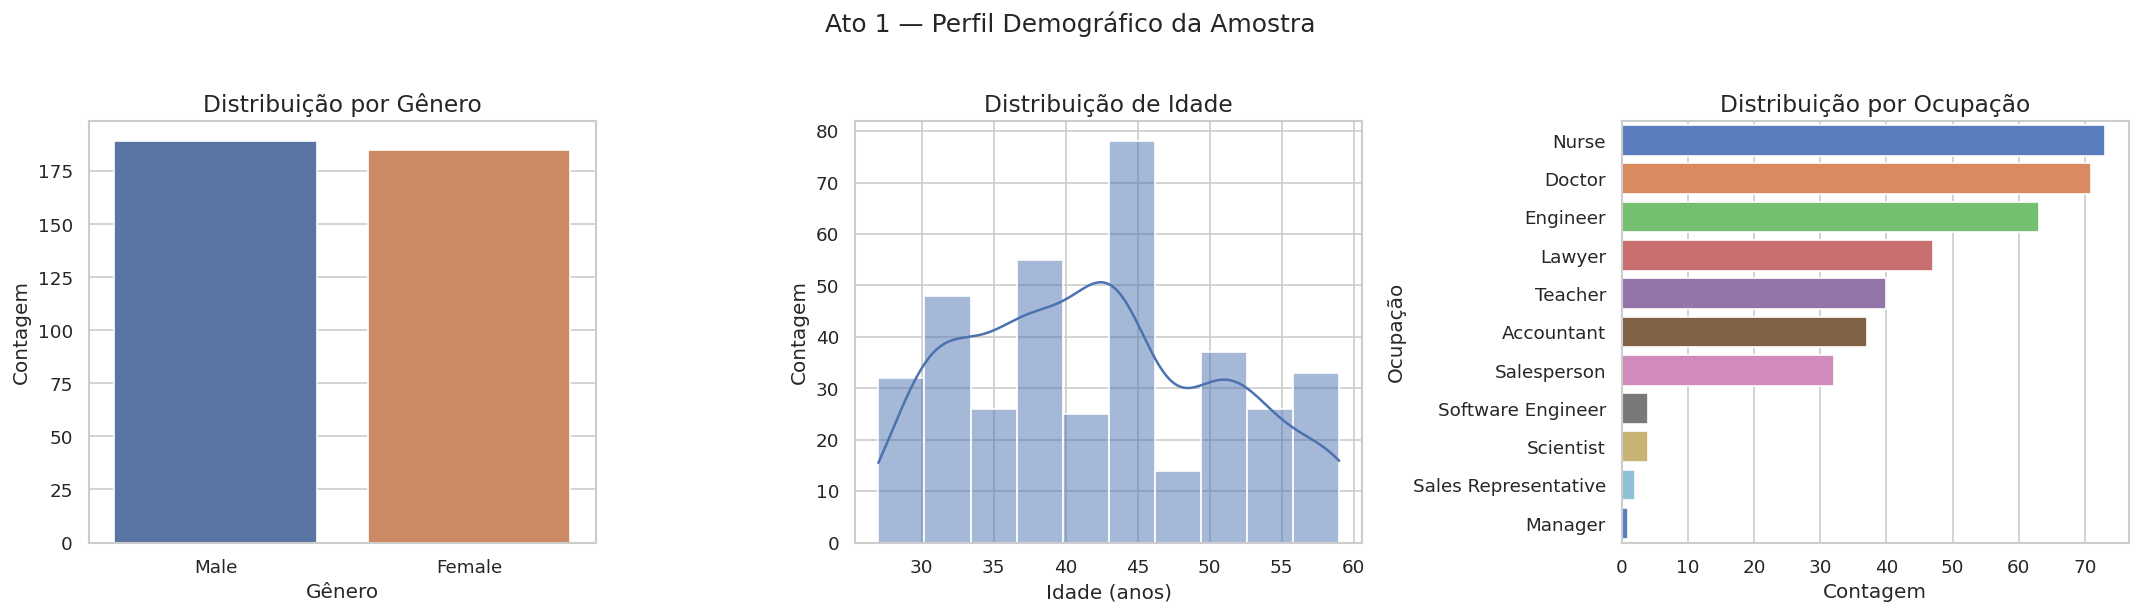

In [32]:
act1_demographic_profile(df)

`IQR = 14.75` significa que os 50% centrais da amostra têm entre ~35 e ~50 anos. Ou seja, metade das pessoas está concentrada nessa faixa etária — adultos em plena vida profissional, o que faz sentido dado que as ocupações dominantes são Nurse, Doctor e Engineer.

**skew_direction = negative** significa que a distribuição é assimétrica à esquerda — a cauda está para a esquerda, ou seja, há mais pessoas acima da média do que abaixo. O histograma confirma: o pico está em torno dos 43-45 anos e a distribuição cai mais suavemente para idades menores. Mean (42.18) < Median (43) confirma o skew negativo.

Para defender que lifestyle influencia o sono, as medidas que mais importam aqui no Ato 1 são:

A `separação por gênero na idade` é a descoberta mais importante — **mulheres têm média de 47 anos e homens 37 anos**. Isso não é trivial. Significa que você está comparando grupos etários diferentes quando compara gêneros, o que pode confundir análises futuras.

A `concentração em profissões de saúde` — Nurse, Doctor, Engineer somam 55% da amostra — introduz um viés importante. Profissionais de saúde têm turnos irregulares, alto estresse e padrões de sono atípicos. Isso já antecipa o Ato 3.

In [33]:
def plot_age_by_gender(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Boxplot de idade por gênero — revela separação etária entre grupos."""
    sns.boxplot(
        data=df,
        x="Gender",
        y="Age",
        palette=_PAL_GENDER,
        order=list(_PAL_GENDER.keys()),
        ax=ax
    )
    ax.set_title("Distribuição de Idade por Gênero")
    ax.set_xlabel("Gênero")
    ax.set_ylabel("Idade (anos)")

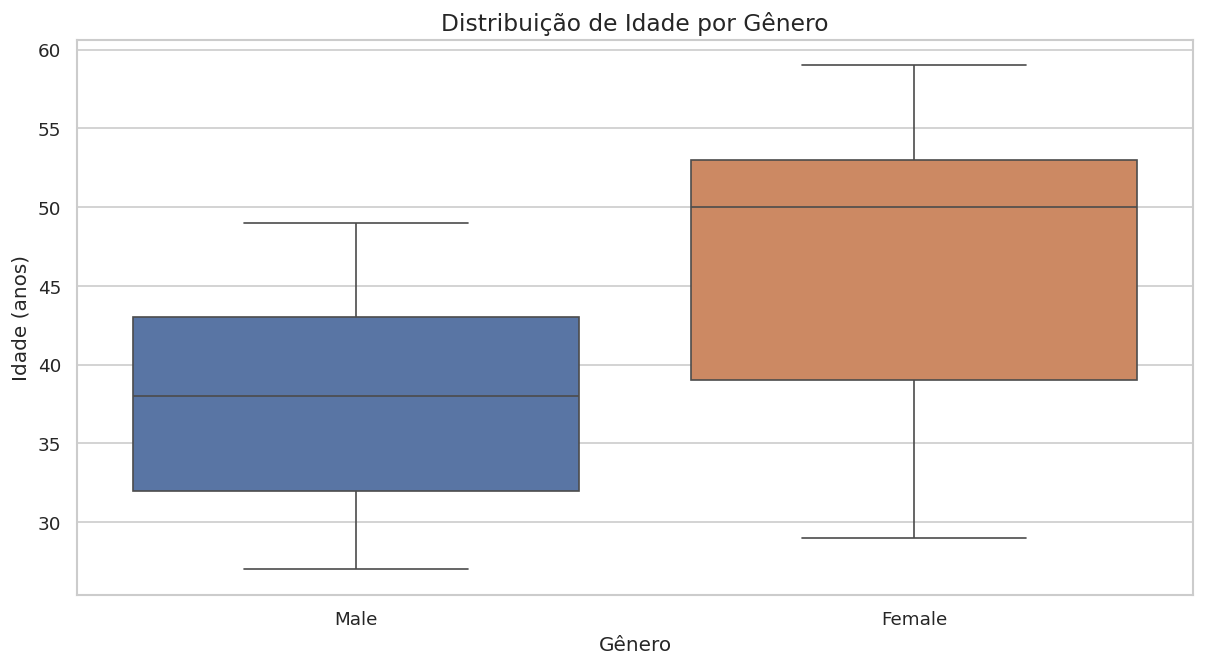

In [34]:
plot_age_by_gender(df, plt.gca())

In [35]:
def plot_occupation_by_gender(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Countplot de ocupação separado por gênero."""
    sns.countplot(
        data=df,
        y="Occupation",
        hue="Gender",
        palette=_PAL_GENDER,
        order=df["Occupation"].value_counts().index,
        ax=ax
    )
    ax.set_title("Ocupação por Gênero")
    ax.set_xlabel("Contagem")
    ax.set_ylabel("Ocupação")

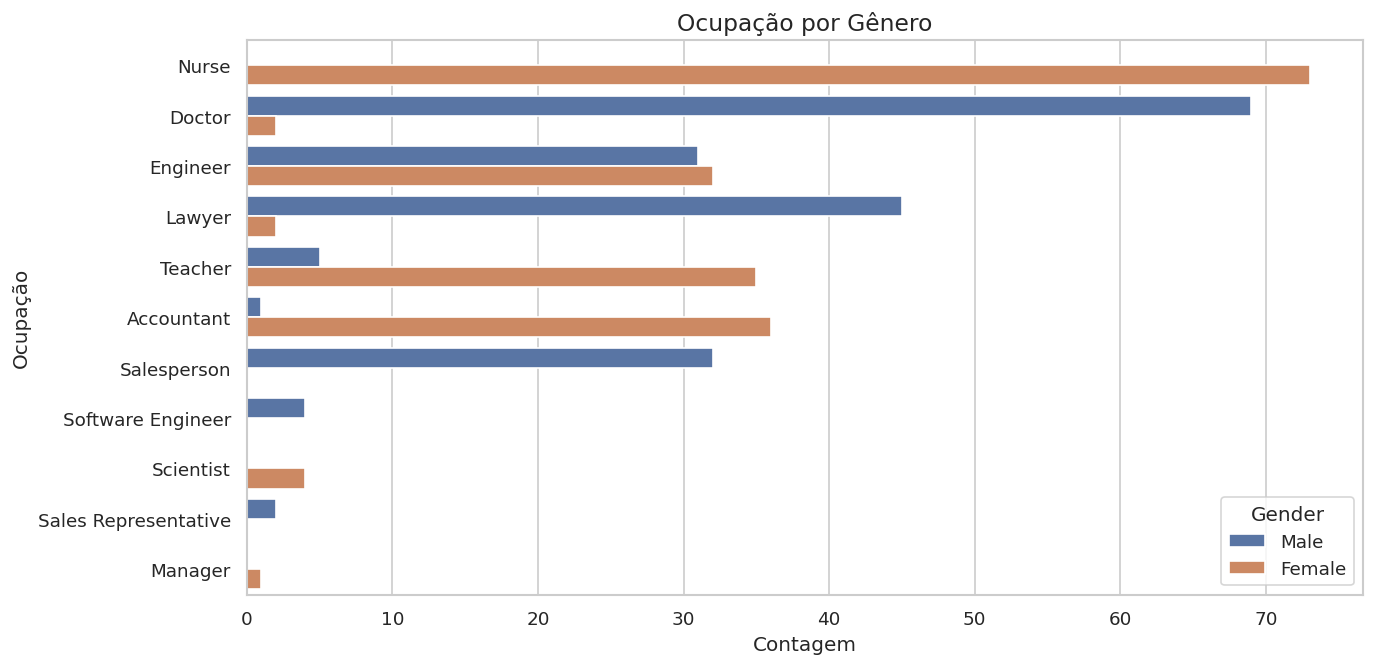

In [36]:
plot_occupation_by_gender(df, plt.gca())

## Da análise de perfil demográfico: Quem são essas pessoas?

"A amostra é composta majoritariamente por profissionais de saúde e engenheiros entre 35 e 50 anos, com uma separação etária relevante entre gêneros. Essas características de perfil profissional — alto estresse, turnos irregulares — `nos levam a investigar se o estilo de vida dessas pessoas impacta diretamente a qualidade do sono`."

## O que um Sênior deve saber em Estatística Descritiva

### 1. Escolher a medida certa para o contexto
- Média → distribuições simétricas, sem outliers significativos
- Mediana → distribuições assimétricas ou com outliers
- Moda → variáveis discretas e ordinais

### 2. Ler Mean vs Median e concluir sobre a forma
- Mean > Median → skew positivo (cauda à direita)
- Mean < Median → skew negativo (cauda à esquerda)
- Mean ≈ Median → distribuição aproximadamente simétrica

### 3. Interpretar dispersão além do desvio padrão
- Std → dispersão geral (assume normalidade)
- IQR → robusto a outliers
- CV → comparar variáveis em escalas diferentes
- Range → simples, mas dominado pelos extremos

### 4. Identificar outliers e investigar o contexto
- Detectar via IQR (Q1 - 1.5×IQR / Q3 + 1.5×IQR) ou z-score
- Não remover automaticamente — investigar se fazem sentido no domínio

### 5. Conectar descrição com hipótese
- Júnior descreve. Sênior interpreta e levanta hipóteses.

### 6. Conhecer os limites
- Correlação não implica causalidade
- Variáveis confundidoras podem explicar relações observadas

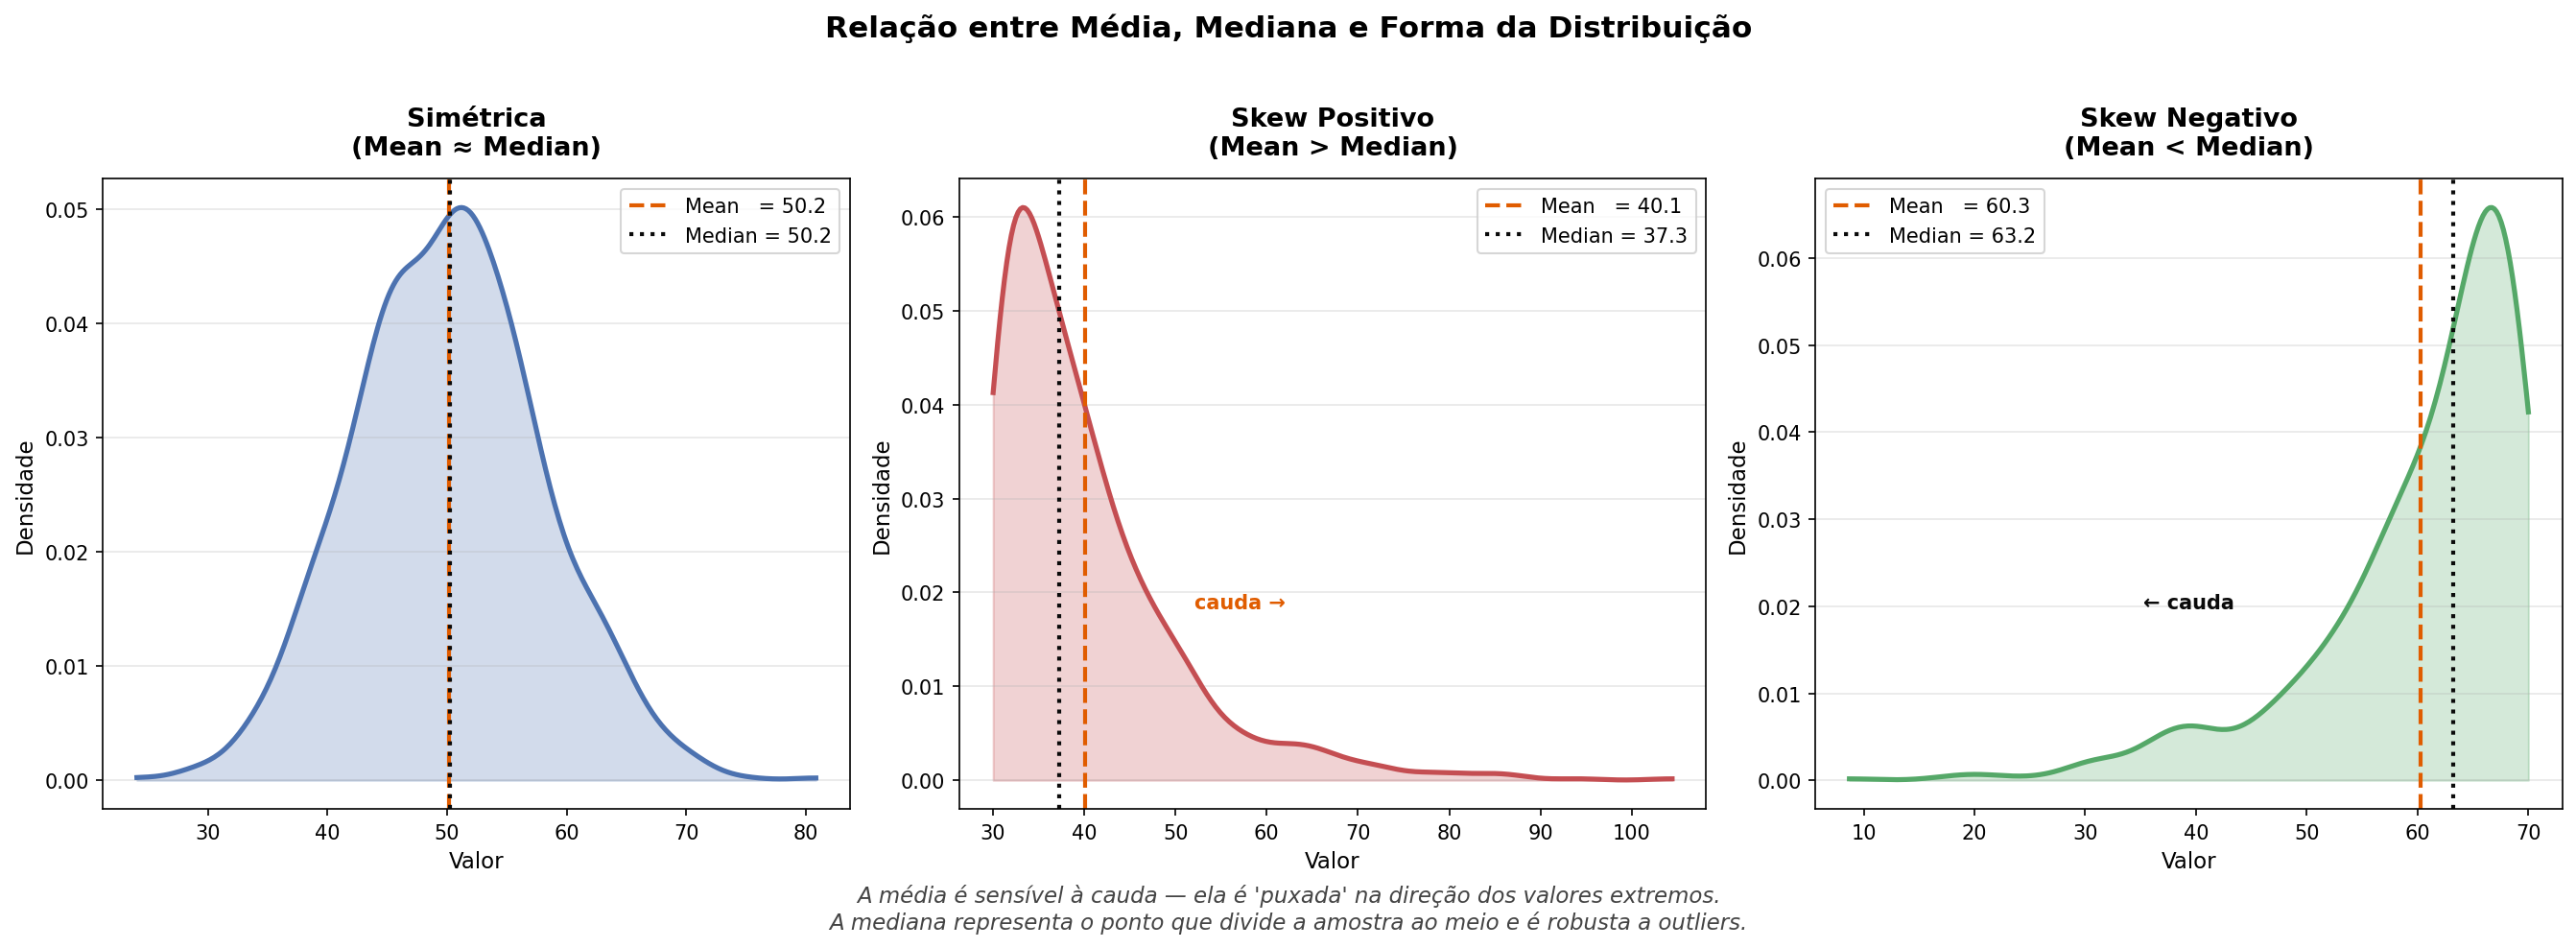

* **median = mean**:
A `mediana` divide a área sob a curva exatamente ao meio — 50% para cada lado. Sempre.

A `média` é puxada pela cauda esquerda para baixo, ficando menor que a mediana. Isso significa que existe uma minoria de valores muito baixos que não representa o comportamento típico, mas arrasta a média.

Então a área maior está entre a média e o lado direito — o lado onde estão a maioria dos valores. É exatamente isso que o nosso dataset de idade mostrou: a maioria das pessoas tem idade acima da média (42.18), com mediana em 43.

A área até a mediana é sempre 50% dos dois lados. O que muda é a **forma** dessa área:

**Skew positivo (mean > median):**
- Área esquerda da mediana: **compacta e alta** — massa concentrada
- Área direita da mediana: **espalhada e baixa** — cauda longa

**Skew negativo (mean < median):**
- Área esquerda da mediana: **espalhada e baixa** — cauda longa
- Área direita da mediana: **compacta e alta** — massa concentrada

---

**Implicação prática — o que isso significa na vida real**

**Skew positivo — renda, preço de imóveis, Daily Steps:**
> A maioria das pessoas ganha pouco, mas uns poucos ganham muito e puxam a média para cima. Se você usar a média como referência, vai superestimar o "típico". A mediana é mais honesta.

**Skew negativo — notas de prova fácil, idade no nosso dataset:**
> A maioria está concentrada em valores altos, mas alguns valores baixos puxam a média para baixo. No nosso dataset: a maioria tem mais de 42 anos, mas alguns indivíduos jovens arrastam a média abaixo da mediana.

---

**Regra de ouro para a prova:**

> *Sempre que a distribuição for assimétrica, a mediana é a medida de centro mais representativa do comportamento típico da amostra.*

In [37]:
def act1_demographic_profile(df: pd.DataFrame) -> None:
    """Ato 1 — Quem são essas pessoas?

    Orquestra as análises univariadas e bivariadas do perfil
    demográfico da amostra. Investiga equilíbrio de gênero,
    distribuição etária, ocupação e o cruzamento entre eles.

    Args:
        df: DataFrame bruto.
    """
    d = _prep(df)
    _section("Ato 1 — Perfil Demográfico: Quem são essas pessoas?")

    # ── Outputs tabulares ─────────────────────────────────────────────────────
    print("\n📊 Gênero — Frequência e Proporção")
    print(frequency_table(d, "Gender").to_string(index=False))

    print("\n📊 Idade — Medidas de Centro e Dispersão")
    print(describe_numeric(d, "Age"))

    print("\n📊 Ocupação — Frequência e Proporção")
    print(frequency_table(d, "Occupation").to_string(index=False))

    print("\n📊 Gênero x Idade — Distribuição por Grupo")
    print(age_by_gender(d))

    # ── Figura 1: visão geral ─────────────────────────────────────────────────
    fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
    fig1.suptitle(
        "Ato 1 — Perfil Demográfico da Amostra",
        fontsize=15, fontweight="bold"
    )
    plot_gender(d, axes1[0])
    plot_age(d, axes1[1])
    plot_occupation(d, axes1[2])
    plt.tight_layout()
    plt.show()

    # ── Figura 2: cruzamento gênero ───────────────────────────────────────────
    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
    fig2.suptitle(
        "Ato 1 — Perfil Demográfico: Cruzamento por Gênero",
        fontsize=15, fontweight="bold"
    )
    plot_age_by_gender(d, axes2[0])
    plot_occupation_by_gender(d, axes2[1])
    plt.tight_layout()
    plt.show()


  Ato 1 — Perfil Demográfico: Quem são essas pessoas?

📊 Gênero — Frequência e Proporção
Gender  count   pct
  Male    189 50.53
Female    185 49.47

📊 Idade — Medidas de Centro e Dispersão
mean                 42.18
median               43.00
mode                    43
std                   8.67
iqr                  14.75
range                   32
cv                   20.56
skew_direction    negative
dtype: object

📊 Ocupação — Frequência e Proporção
          Occupation  count   pct
               Nurse     73 19.52
              Doctor     71 18.98
            Engineer     63 16.84
              Lawyer     47 12.57
             Teacher     40 10.70
          Accountant     37  9.89
         Salesperson     32  8.56
   Software Engineer      4  1.07
           Scientist      4  1.07
Sales Representative      2  0.53
             Manager      1  0.27

📊 Gênero x Idade — Distribuição por Grupo
        count  mean  median  std  min  max
Gender                                    
Femal

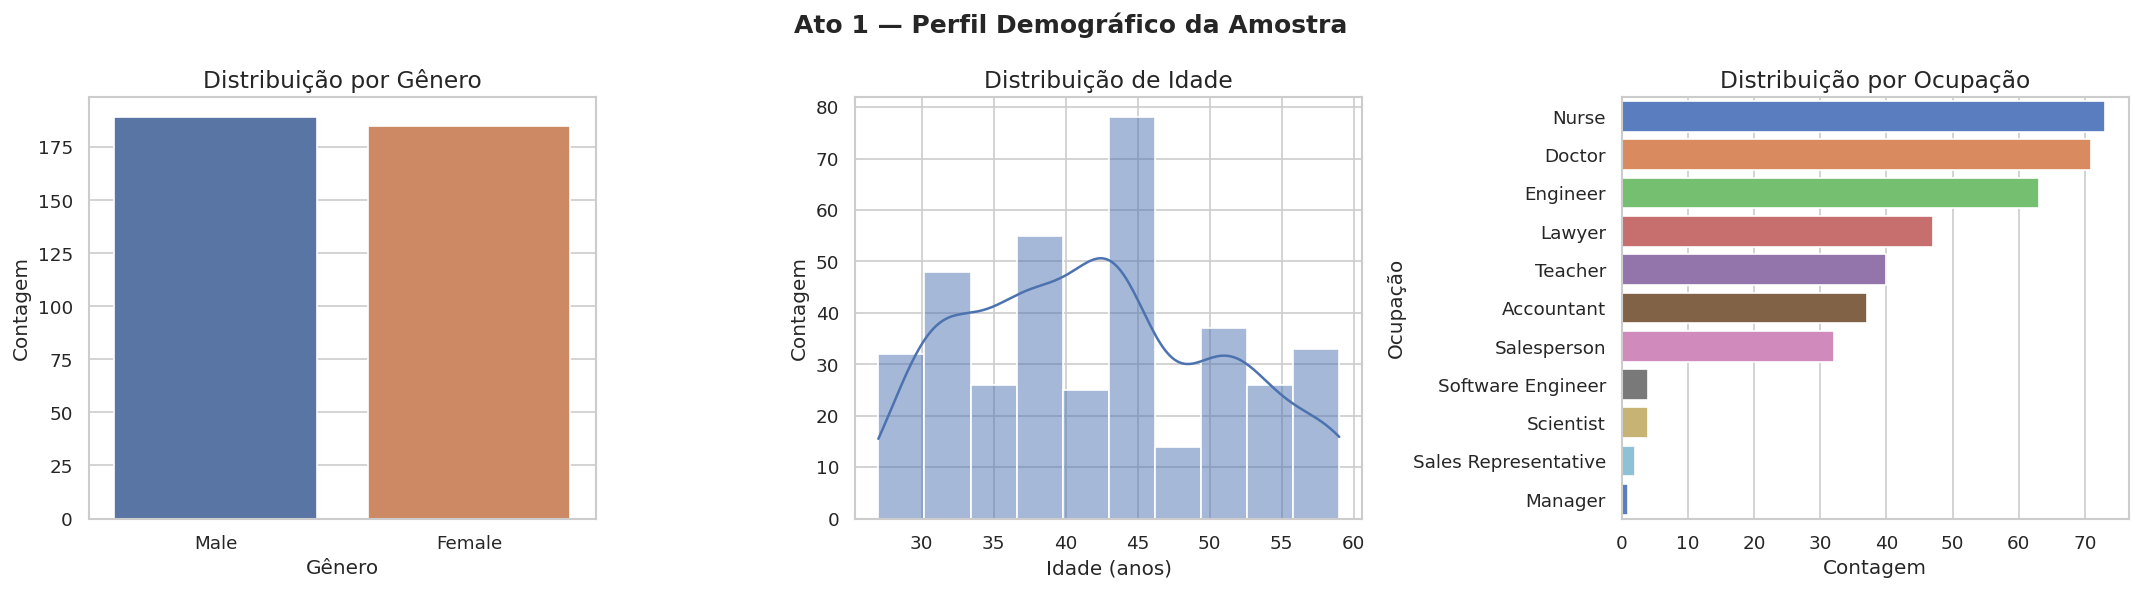

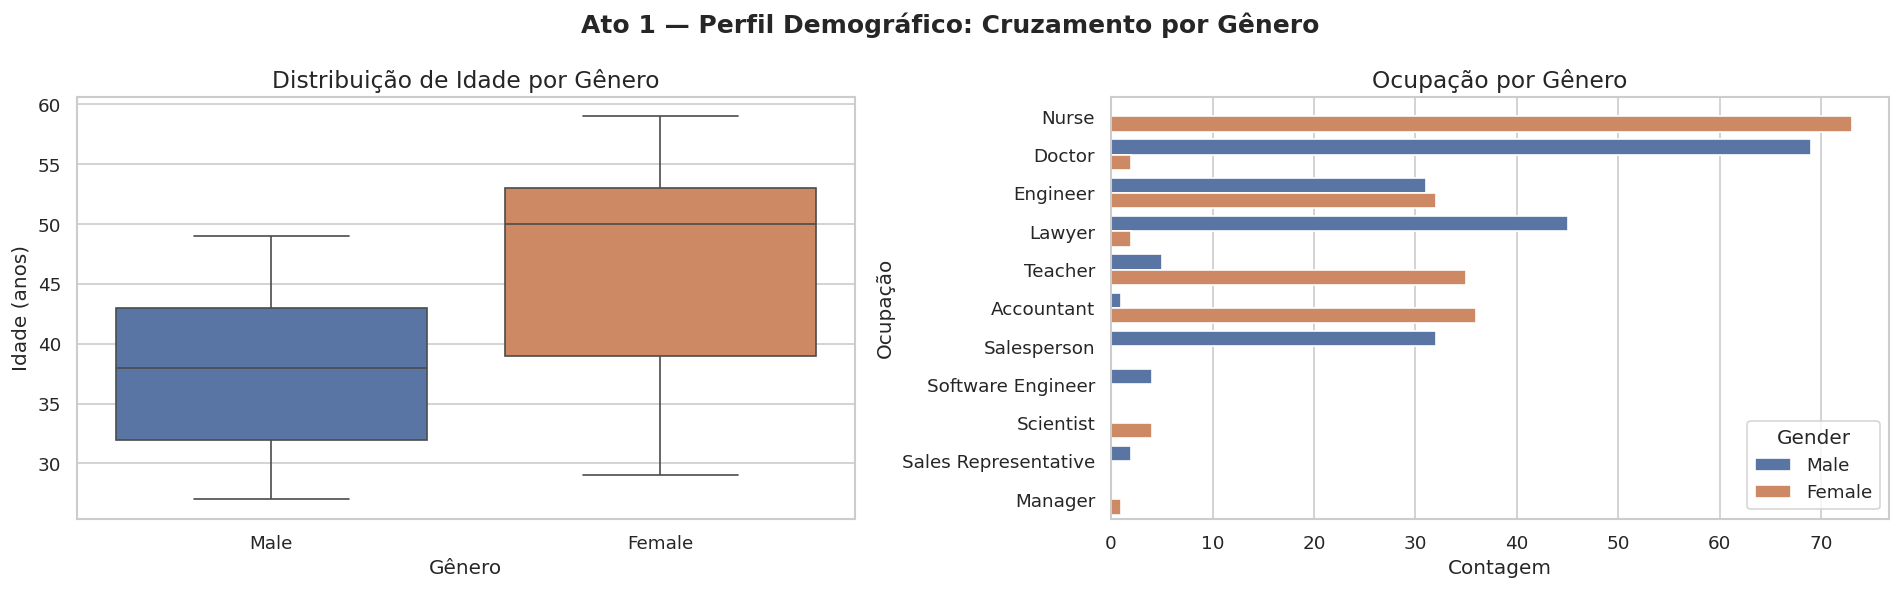

In [38]:
act1_demographic_profile(df)

## Ato 1 — Conclusão: Quem são essas pessoas?

A amostra é equilibrada em gênero (50/50), mas apresenta dois
vieses importantes que devem ser considerados nos atos seguintes:

1. **Viés etário por gênero:** mulheres são significativamente
   mais velhas (mediana 50 anos) do que homens (mediana 38 anos),
   explicado pela concentração feminina em Enfermagem e masculina
   em Engenharia e Direito.

2. **Viés de ocupação:** 55% da amostra são Nurses, Doctors e
   Engineers — profissões com alto estresse e padrões de sono
   atípicos, o que antecipa os resultados dos Atos 3 e 4.

> Esses vieses não invalidam a análise, mas precisam ser
> considerados ao interpretar as relações entre lifestyle e sono.

Exatamente! E você acabou de fazer algo que é marca registrada de um sênior — **conectar o viés da amostra com uma hipótese de negócio**.

---

**Desenvolvendo o raciocínio**

O que você identificou é um **confounding variable** clássico:

```
Gênero → Ocupação → Idade → Estresse → Burnout/Sleep Disorder
```

Não é o gênero em si que aumenta o risco de burnout — é o fato de que mulheres nessa amostra estão concentradas em ocupações de alta demanda emocional e física (Enfermagem principalmente), com idade mais avançada, o que amplifica o efeito.

---

**Se esse fosse um estudo completo, o que faríamos:**

**1. Estratificar a análise** — nunca comparar homens vs mulheres diretamente sem controlar pela ocupação. A comparação justa seria Nurse homem vs Nurse mulher, Doctor homem vs Doctor mulher.

**2. Investigar causalidade reversa** — burnout causa má qualidade de sono, ou má qualidade de sono ao longo do tempo causa burnout? Com dados transversais como esse dataset, não conseguimos responder — precisaríamos de dados longitudinais.

**3. Calcular risco relativo por grupo** — qual a proporção de Sleep Disorder dentro de cada subgrupo Gênero x Ocupação? Isso já seria uma análise bivariada com implicação preditiva.

---

**A frase que resume para a prova:**

> *"Correlação entre gênero e Sleep Disorder nessa amostra pode ser espúria — a variável confundidora é a ocupação. Sem estratificar por ocupação, qualquer conclusão sobre gênero e sono é potencialmente enganosa."*

Isso é o tipo de resposta que diferencia um sênior na prova. Quer seguir para o Ato 2?

## Ato 2 - Como as pessoas vivem (lifestyle)?
### Variáveis do Ato 2

| Variável | Tipo | O que mede |
|----------|------|------------|
| Physical Activity Level | Inteira | Minutos de atividade física/dia |
| Daily Steps | Inteira | Passos por dia |
| Stress Level | Ordinal | Escala 1-10 |
| Sleep Duration | Contínua | Horas de sono/dia |
| Quality of Sleep | Ordinal | Escala 1-10 |

In [40]:
def lifestyle_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula medidas de centro e dispersão para todas as
    variáveis de lifestyle.

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com métricas para cada variável de lifestyle.
    """
    lifestyle_cols = [
        "Physical Activity Level",
        "Daily Steps",
        "Stress Level",
        "Sleep Duration",
        "Quality of Sleep"
    ]
    return pd.DataFrame(
        {col: describe_numeric(df, col) for col in lifestyle_cols}
    ).T

In [41]:
def plot_lifestyle_distributions(df: pd.DataFrame) -> None:
    """Histogramas com KDE para cada variável de lifestyle.

    Permite identificar forma da distribuição, skewness
    e concentração de valores para cada variável.

    Args:
        df: DataFrame padronizado.
    """
    lifestyle_cols = [
        "Physical Activity Level",
        "Daily Steps",
        "Stress Level",
        "Sleep Duration",
        "Quality of Sleep"
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        "Ato 2 — Distribuição das Variáveis de Lifestyle",
        fontsize=15, fontweight="bold"
    )
    axes = axes.flatten()

    for i, col in enumerate(lifestyle_cols):
        mean   = df[col].mean()
        median = df[col].median()

        sns.histplot(data=df, x=col, kde=True, color="#4c72b0", ax=axes[i])
        axes[i].axvline(mean,   color="#e05c00", linestyle="--",
                        linewidth=1.8, label=f"Mean={mean:.1f}")
        axes[i].axvline(median, color="#0a0a0a", linestyle=":",
                        linewidth=1.8, label=f"Median={median:.1f}")
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].legend(fontsize=9)

    # Remove eixo extra
    axes[-1].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_lifestyle_boxplots(df: pd.DataFrame) -> None:
    """Boxplots para identificar outliers em cada variável de lifestyle.

    Args:
        df: DataFrame padronizado.
    """
    lifestyle_cols = [
        "Physical Activity Level",
        "Daily Steps",
        "Stress Level",
        "Sleep Duration",
        "Quality of Sleep"
    ]

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(
        "Ato 2 — Outliers nas Variáveis de Lifestyle",
        fontsize=15, fontweight="bold"
    )

    for i, col in enumerate(lifestyle_cols):
        sns.boxplot(data=df, y=col, color="#4c72b0", ax=axes[i])
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("")

    plt.tight_layout()
    plt.show()

In [42]:
def act2_lifestyle_profile(df: pd.DataFrame) -> None:
    """Ato 2 — Como elas vivem?

    Análise univariada das variáveis de lifestyle.
    Investiga distribuição, centro, dispersão e outliers
    para identificar padrões que antecipam problemas de sono.

    Args:
        df: DataFrame bruto.
    """
    d = _prep(df)
    _section("Ato 2 — Lifestyle: Como elas vivem?")

    print("\n📊 Resumo das Variáveis de Lifestyle")
    print(lifestyle_summary(d).to_string())

    plot_lifestyle_distributions(d)
    plot_lifestyle_boxplots(d)


  Ato 2 — Lifestyle: Como elas vivem?

📊 Resumo das Variáveis de Lifestyle
                           mean  median  mode     std     iqr range    cv skew_direction
Physical Activity Level   59.17   60.00    60   20.83   30.00    60 35.20       negative
Daily Steps             6816.84 7000.00  8000 1617.92 2400.00  7000 23.73       negative
Stress Level               5.39    5.00     3    1.77    3.00     5 32.95       positive
Sleep Duration             7.13    7.20  7.20    0.80    1.40  2.70 11.16       negative
Quality of Sleep           7.31    7.00     8    1.20    2.00     5 16.37       positive


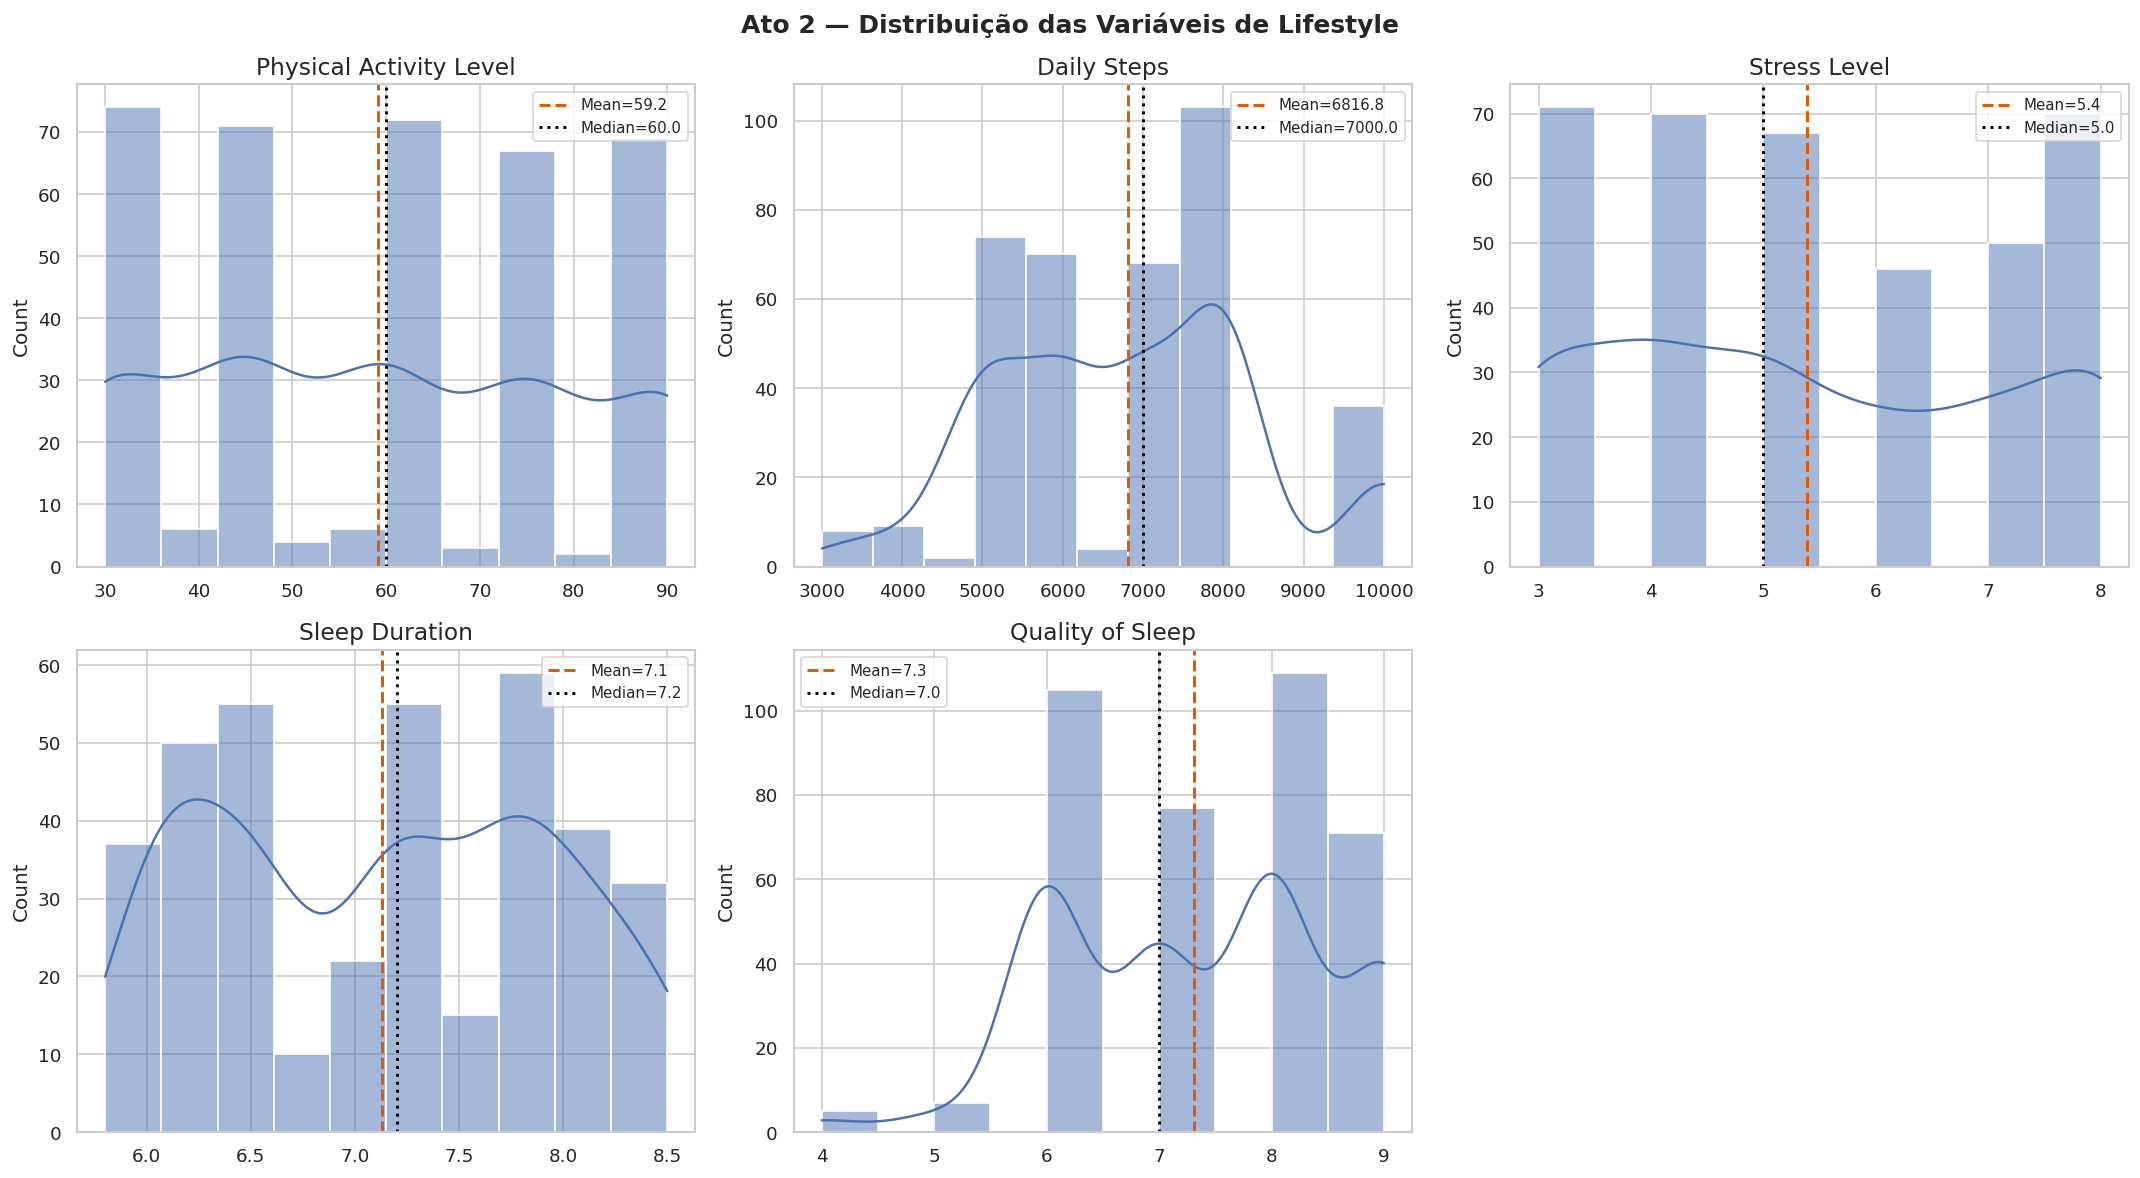

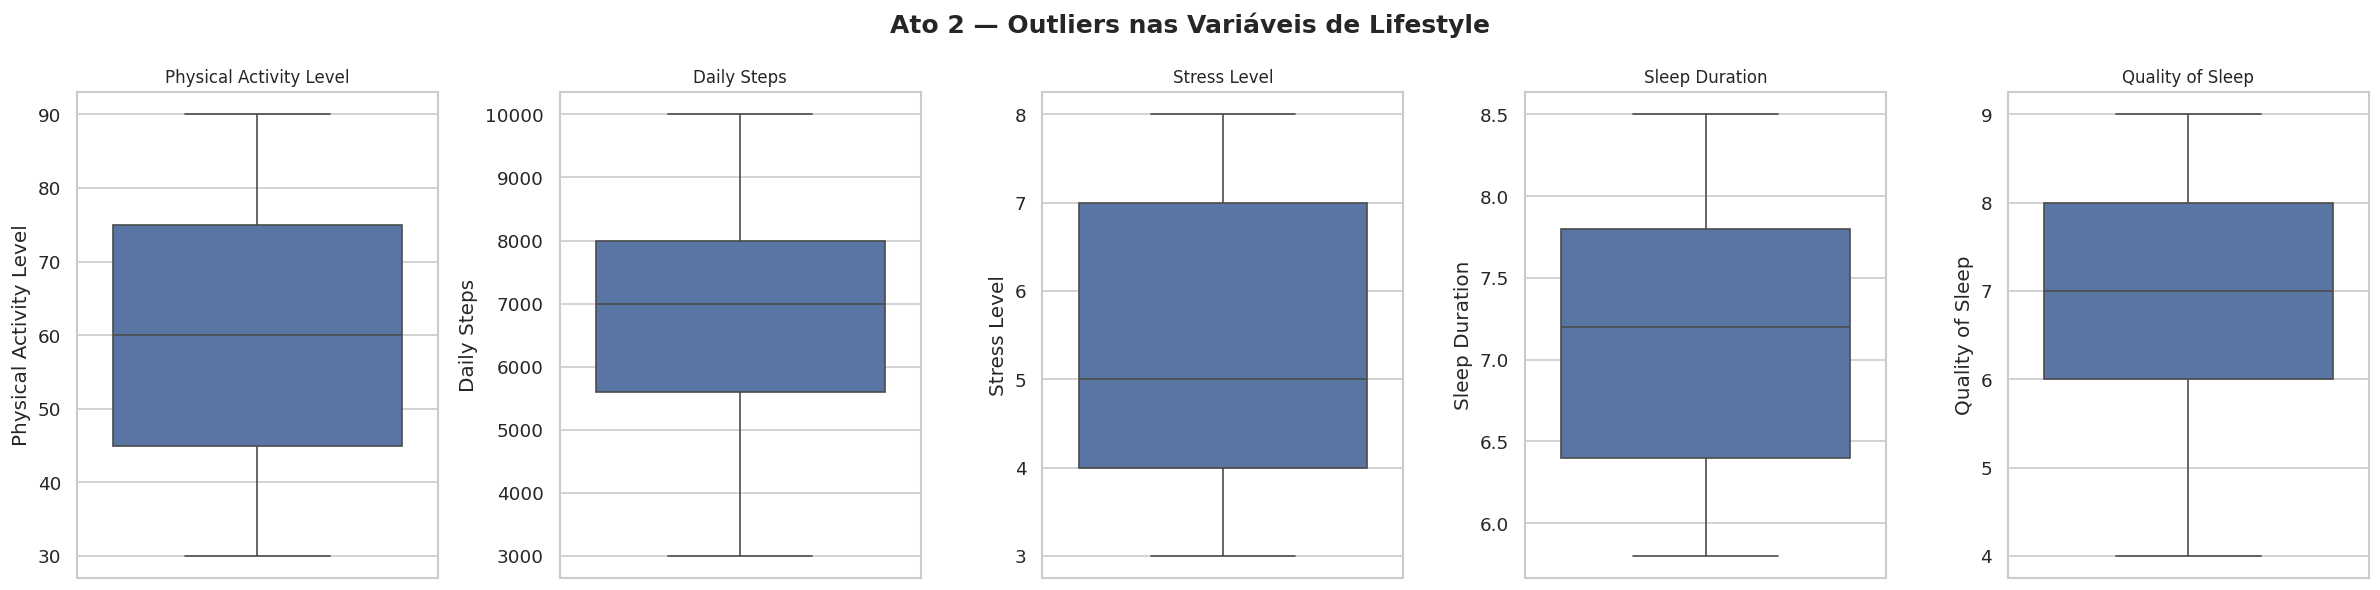

In [43]:
act2_lifestyle_profile(df)

In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def plot_lifestyle_boxplots_interactive(df: pd.DataFrame) -> None:
    """Boxplots interativos das variáveis de lifestyle usando Plotly.

    Permite visualizar Q1, Q3, IQR, mediana e outliers
    ao passar o mouse sobre cada elemento do gráfico.

    Args:
        df: DataFrame padronizado.
    """
    lifestyle_cols = [
        "Physical Activity Level",
        "Daily Steps",
        "Stress Level",
        "Sleep Duration",
        "Quality of Sleep"
    ]

    fig = make_subplots(
        rows=1, cols=5,
        subplot_titles=lifestyle_cols
    )

    colors = [
        "#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2"
    ]

    for i, (col, color) in enumerate(zip(lifestyle_cols, colors), start=1):
        fig.add_trace(
            go.Box(
                y=df[col],
                name=col,
                marker_color=color,
                boxmean=True,       # mostra a média como linha tracejada
                boxpoints="outliers",  # mostra apenas os outliers
                hovertemplate=(
                    "<b>%{x}</b><br>"
                    "Max: %{upperfence}<br>"
                    "Q3: %{q3}<br>"
                    "Median: %{median}<br>"
                    "Mean: %{mean}<br>"
                    "Q1: %{q1}<br>"
                    "Min: %{lowerfence}<br>"
                    "<extra></extra>"
                )
            ),
            row=1, col=i
        )

    fig.update_layout(
        title=dict(
            text="Ato 2 — Outliers nas Variáveis de Lifestyle (Interativo)",
            font=dict(size=16),
            x=0.5
        ),
        showlegend=False,
        height=500,
        width=1200,
        template="plotly_white",
    )

    fig.show()

In [45]:
def plot_lifestyle_distributions_interactive(df: pd.DataFrame) -> None:
    """Histogramas interativos com linhas de média e mediana usando Plotly.

    Args:
        df: DataFrame padronizado.
    """
    lifestyle_cols = [
        "Physical Activity Level",
        "Daily Steps",
        "Stress Level",
        "Sleep Duration",
        "Quality of Sleep"
    ]

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=lifestyle_cols,
        vertical_spacing=0.15
    )

    colors = [
        "#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2"
    ]

    positions = [(1,1), (1,2), (1,3), (2,1), (2,2)]

    for (row, col_pos), col, color in zip(positions, lifestyle_cols, colors):
        mean   = df[col].mean()
        median = df[col].median()

        # Histograma
        fig.add_trace(
            go.Histogram(
                x=df[col],
                name=col,
                marker_color=color,
                opacity=0.7,
                hovertemplate="Valor: %{x}<br>Count: %{y}<extra></extra>"
            ),
            row=row, col=col_pos
        )

        # Linha da média
        fig.add_vline(
            x=mean,
            line_dash="dash",
            line_color="#e05c00",
            line_width=2,
            annotation_text=f"Mean={mean:.1f}",
            annotation_font_color="#e05c00",
            row=row, col=col_pos
        )

        # Linha da mediana
        fig.add_vline(
            x=median,
            line_dash="dot",
            line_color="#0a0a0a",
            line_width=2,
            annotation_text=f"Median={median:.1f}",
            annotation_font_color="#0a0a0a",
            row=row, col=col_pos
        )

    fig.update_layout(
        title=dict(
            text="Ato 2 — Distribuição das Variáveis de Lifestyle (Interativo)",
            font=dict(size=16),
            x=0.5
        ),
        showlegend=False,
        height=700,
        width=1200,
        template="plotly_white",
    )

    fig.show()

|----[  Q1 ====== MEDIANA ====== Q3  ]-----|
     mínimo                          máximo
      whisker                        whisker

IQR = Q3 - Q1 — é literalmente a largura da caixa no boxplot.

---

**IQR — o que é visualmente no boxplot**

O boxplot tem 5 elementos:

```
|----[  Q1 ====== MEDIANA ====== Q3  ]-----|
     mínimo                          máximo
      whisker                        whisker
```

**IQR = Q3 - Q1** — é literalmente **a largura da caixa** no boxplot.

---

**Aplicando nos seus dados**

**Physical Activity Level — IQR = 30**
Olha a caixa no boxplot: ela vai de ~45 a ~75. Os 50% centrais da amostra praticam entre 45 e 75 minutos de atividade por dia. Uma variação de 30 minutos dentro do grupo central — relativamente ampla, confirmando o std alto de 20.83.

**Daily Steps — IQR = 2400**
A caixa vai de ~5600 a ~8000 passos. Os 50% centrais caminham entre 5600 e 8000 passos/dia. Amplo também — pessoas muito sedentárias convivem com pessoas bem ativas na mesma amostra.

**Stress Level — IQR = 3**
A caixa vai de ~4 a ~7. Os 50% centrais têm estresse entre 4 e 7 numa escala de 1-10. Isso é bastante — significa que metade da amostra está na faixa de estresse moderado a alto.

**Sleep Duration — IQR = 1.4**
A caixa é estreita — de ~6.4 a ~7.8 horas. Os 50% centrais dormem entre 6.4 e 7.8 horas. Pouca variação, confirma o std baixo de 0.80.

**Quality of Sleep — IQR = 2**
A caixa vai de ~6 a ~8. Os 50% centrais avaliam o sono entre 6 e 8. Razoavelmente concentrado.

---

**A regra prática para ler IQR:**

```
IQR pequeno → caixa estreita → 50% centrais concentrados → baixa dispersão
IQR grande  → caixa larga   → 50% centrais espalhados   → alta dispersão
```

---

**Conectando com sua interpretação:**

Você estava certo no raciocínio — Physical Activity e Daily Steps têm alta variabilidade tanto no std quanto no IQR, confirmando pelos dois ângulos. Sleep Duration e Quality of Sleep têm baixa variabilidade pelos dois também. O Stress Level é o mais interessante — std alto, IQR = 3, e skew positivo — uma minoria com estresse muito alto puxando a média acima da mediana.

Essa minoria de alto estresse é exatamente o grupo que vamos investigar no Ato 3. Faz sentido agora?

In [46]:
plot_lifestyle_boxplots_interactive(df)             # plotly — interativo


In [47]:
plot_lifestyle_distributions_interactive(df)        # plotly — interativo

**Ato 3 — Lifestyle afeta o sono?**

A pergunta guia é:

> *"As pessoas que vivem de forma mais ativa e menos estressada dormem melhor?"*

Aqui saímos da análise univariada e entramos na **bivariada** — cruzando lifestyle com qualidade e duração do sono.

---

**As relações que vamos investigar:**

```markdown
## Hipóteses do Ato 3

| Variável X (Lifestyle) | Variável Y (Sono) | Hipótese |
|------------------------|-------------------|----------|
| Stress Level | Quality of Sleep | Mais estresse → pior sono |
| Stress Level | Sleep Duration | Mais estresse → menos horas |
| Physical Activity Level | Quality of Sleep | Mais atividade → melhor sono |
| Daily Steps | Quality of Sleep | Mais passos → melhor sono |
| Occupation | Sleep Duration | Ocupação influencia horas dormidas |
```
Antes de rodar — com base no que já vimos no Ato 2, o que você espera encontrar nas correlações? O Stress Level deve ter correlação negativa forte com Quality of Sleep — mas Physical Activity pode surpreender. Rode e me traz os outputs!

In [48]:
def correlation_lifestyle_sleep(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula correlação de Spearman entre variáveis de lifestyle e sono.

    Spearman é mais adequado aqui pois Stress Level e Quality of Sleep
    são ordinais — não assumimos distribuição normal nem intervalos uniformes.

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com correlações e p-values.
    """
    from scipy.stats import spearmanr

    lifestyle_cols = [
        "Physical Activity Level",
        "Daily Steps",
        "Stress Level",
    ]
    sleep_cols = ["Quality of Sleep", "Sleep Duration"]

    results = []
    for lc in lifestyle_cols:
        for sc in sleep_cols:
            corr, p = spearmanr(df[lc], df[sc])
            results.append({
                "lifestyle_var": lc,
                "sleep_var":     sc,
                "spearman_r":    round(corr, 3),
                "p_value":       _fmt_p(p),
                "strength":      _corr_strength(corr)
            })

    return pd.DataFrame(results)


def _corr_strength(r: float) -> str:
    """Classifica a força da correlação pelo valor absoluto de r.

    Args:
        r: Coeficiente de correlação.

    Returns:
        str: Classificação da força da correlação.
    """
    r = abs(r)
    if r >= 0.7:
        return "strong"
    elif r >= 0.4:
        return "moderate"
    elif r >= 0.2:
        return "weak"
    else:
        return "negligible"

In [49]:
def plot_stress_vs_sleep(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Boxplot de Quality of Sleep por nível de Stress.

    Permite ver como a distribuição da qualidade do sono
    muda à medida que o estresse aumenta.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    sns.boxplot(
        data=df,
        x="Stress Level",
        y="Quality of Sleep",
        palette="coolwarm",
        ax=ax
    )
    ax.set_title("Stress Level vs Quality of Sleep")
    ax.set_xlabel("Stress Level (1-10)")
    ax.set_ylabel("Quality of Sleep (1-10)")


def plot_activity_vs_sleep(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Scatter de Physical Activity Level vs Quality of Sleep.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    sns.scatterplot(
        data=df,
        x="Physical Activity Level",
        y="Quality of Sleep",
        hue="Stress Level",
        palette="coolwarm",
        alpha=0.7,
        ax=ax
    )
    ax.set_title("Physical Activity vs Quality of Sleep\n(cor = Stress Level)")
    ax.set_xlabel("Physical Activity (min/day)")
    ax.set_ylabel("Quality of Sleep (1-10)")


def plot_occupation_vs_sleep(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Boxplot de Sleep Duration por ocupação.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    order = (
        df.groupby("Occupation")["Sleep Duration"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    sns.boxplot(
        data=df,
        x="Sleep Duration",
        y="Occupation",
        order=order,
        palette="muted",
        ax=ax
    )
    ax.set_title("Ocupação vs Sleep Duration")
    ax.set_xlabel("Sleep Duration (horas)")
    ax.set_ylabel("Ocupação")


def plot_correlation_heatmap_lifestyle(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Heatmap de correlação entre lifestyle e variáveis de sono.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    cols = [
        "Physical Activity Level",
        "Daily Steps",
        "Stress Level",
        "Sleep Duration",
        "Quality of Sleep"
    ]
    corr = df[cols].corr(method="spearman")
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=ax,
        linewidths=0.5
    )
    ax.set_title("Correlação de Spearman — Lifestyle vs Sono")




  Ato 3 — Lifestyle afeta o sono?

📊 Correlação de Spearman — Lifestyle vs Sono
          lifestyle_var        sleep_var  spearman_r    p_value   strength
Physical Activity Level Quality of Sleep        0.18 p = 0.0005 negligible
Physical Activity Level   Sleep Duration        0.21 p < 0.0001       weak
            Daily Steps Quality of Sleep        0.02 p = 0.6606 negligible
            Daily Steps   Sleep Duration        0.01 p = 0.8458 negligible
           Stress Level Quality of Sleep       -0.91 p < 0.0001     strong
           Stress Level   Sleep Duration       -0.81 p < 0.0001     strong


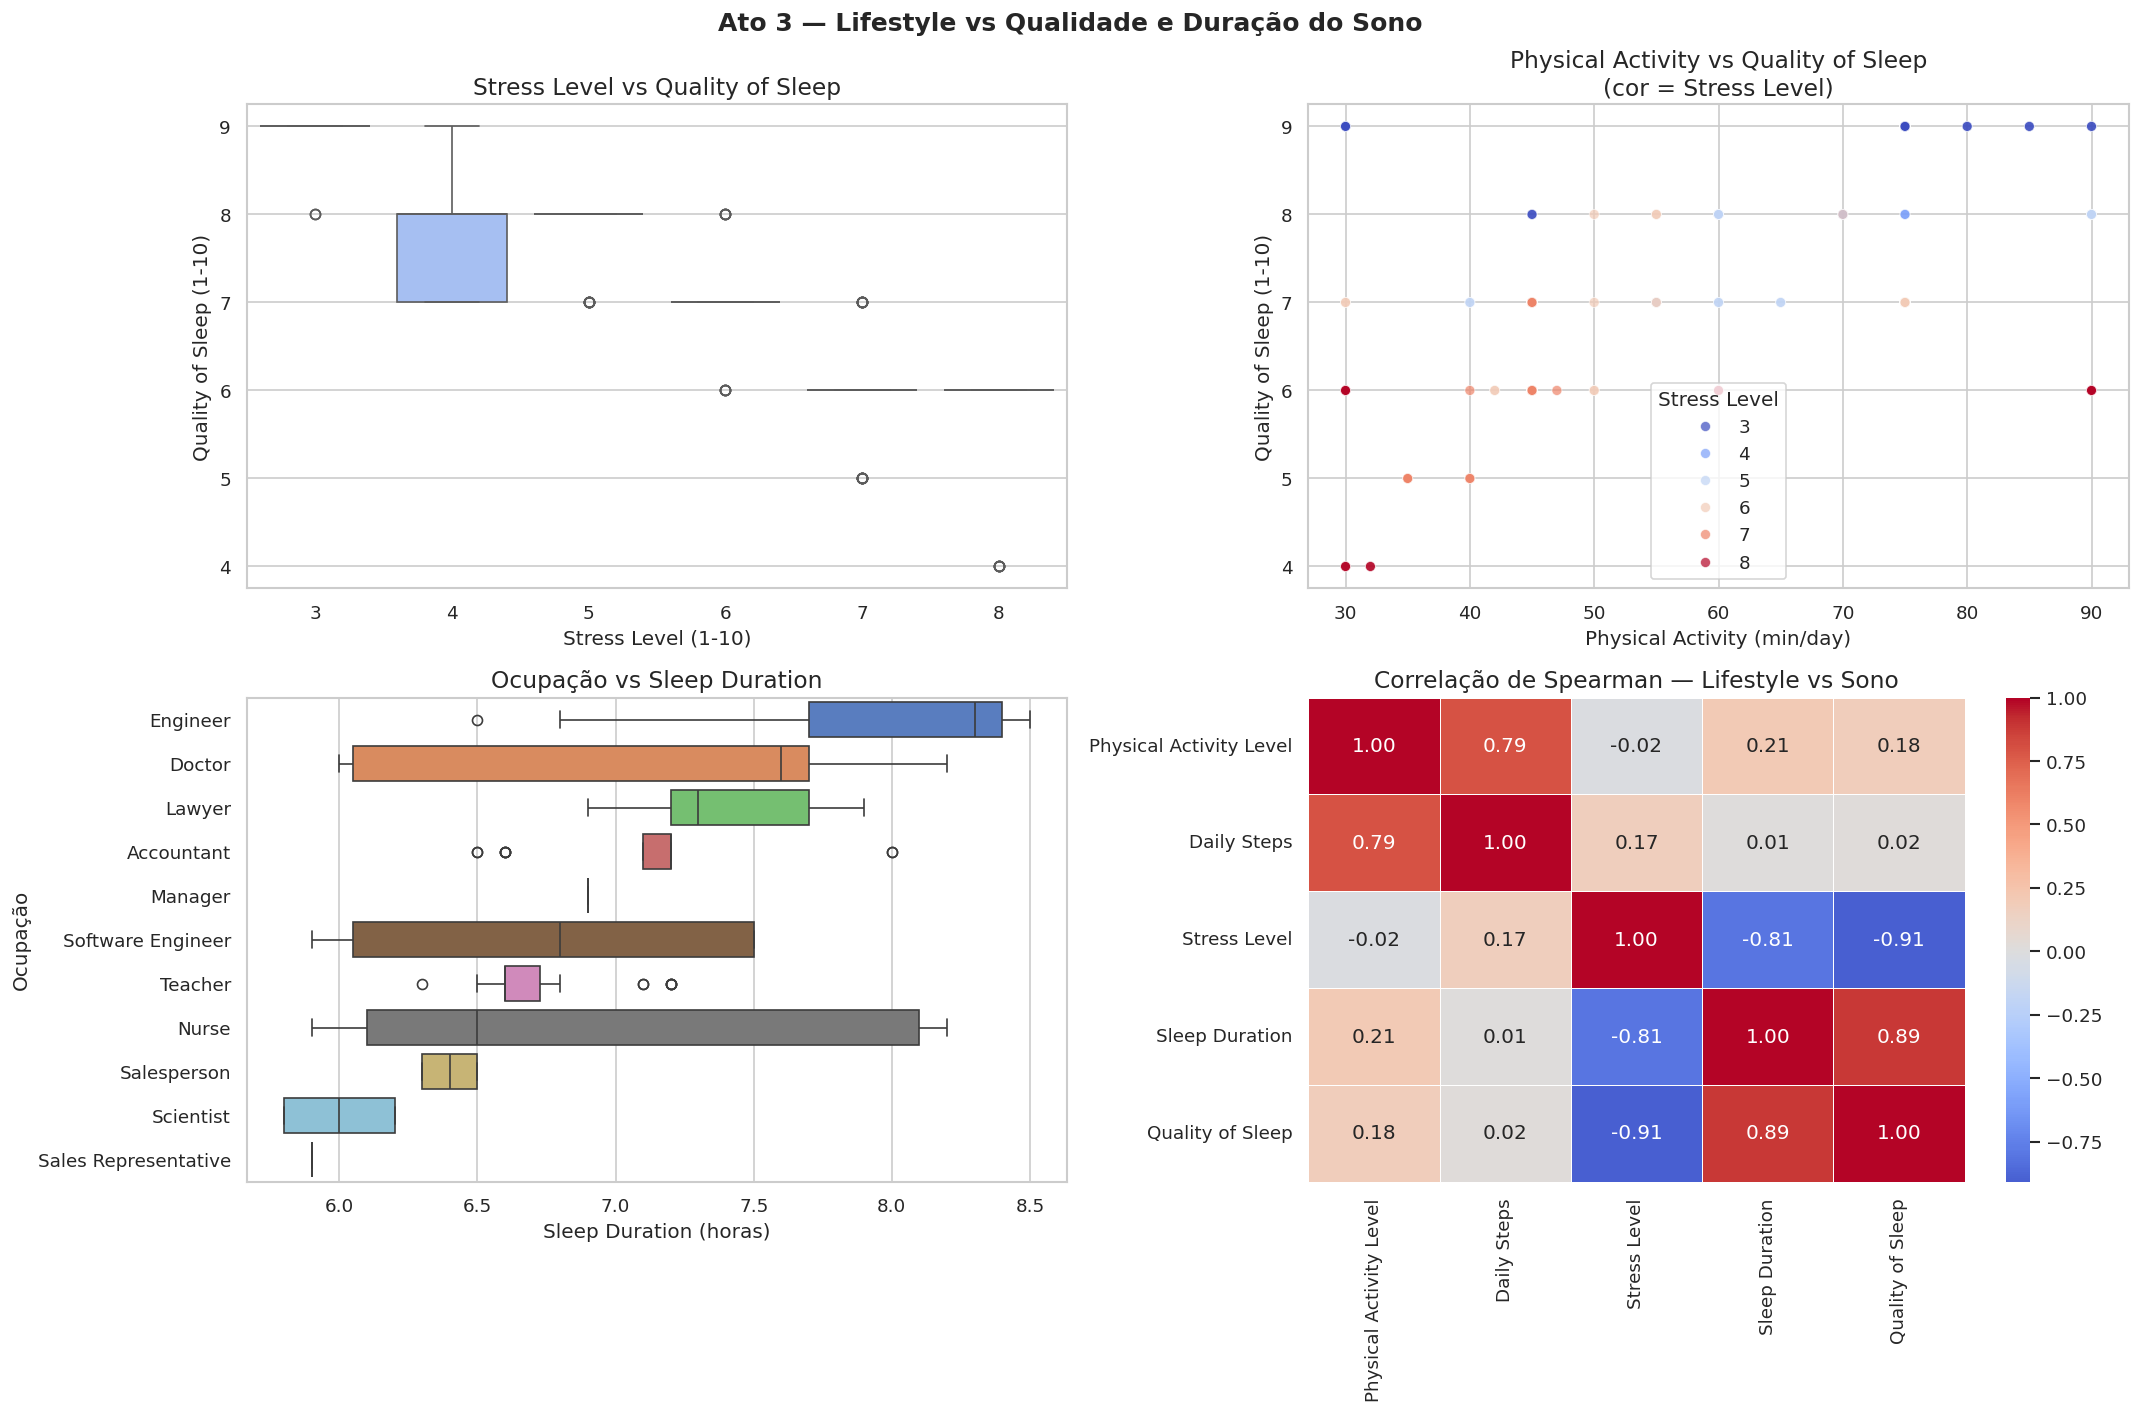

In [50]:
def act3_lifestyle_vs_sleep(df: pd.DataFrame) -> None:
    """Ato 3 — Lifestyle afeta o sono?

    Análise bivariada entre variáveis de lifestyle e qualidade/duração
    do sono. Usa correlação de Spearman por lidar com variáveis ordinais.

    Args:
        df: DataFrame bruto.
    """
    d = _prep(df)
    _section("Ato 3 — Lifestyle afeta o sono?")

    print("\n📊 Correlação de Spearman — Lifestyle vs Sono")
    print(correlation_lifestyle_sleep(d).to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(
        "Ato 3 — Lifestyle vs Qualidade e Duração do Sono",
        fontsize=15, fontweight="bold"
    )

    plot_stress_vs_sleep(d, axes[0, 0])
    plot_activity_vs_sleep(d, axes[0, 1])
    plot_occupation_vs_sleep(d, axes[1, 0])
    plot_correlation_heatmap_lifestyle(d, axes[1, 1])

    plt.tight_layout()
    plt.show()

act3_lifestyle_vs_sleep(df)


Excelente análise! E sua honestidade intelectual de reconhecer o viés prévio é exatamente o que diferencia um bom cientista de dados.

---

**Validando suas observações:**

Você identificou corretamente os pontos mais importantes:

**Ocupação vs Sono** — Engineers dormindo melhor faz sentido quando cruzamos com o Ato 1: Engineers são majoritariamente homens mais jovens, com menor IQR de idade. Nurses têm IQR alto de sono — turnos noturnos explicam essa dispersão grande. Doctors com IQR alto também — plantões irregulares.

**Daily Steps negligenciável** — isso é uma descoberta importante. Intuitivamente esperaríamos que mais passos = melhor sono, mas os dados não confirmam. Isso sugere que **o que importa não é quantidade de movimento, mas a intensidade** — Physical Activity Level (minutos de exercício) tem correlação mais forte do que simplesmente contar passos.

**Stress Level como grande influenciador** — você confirmou com dados o que sua experiência com apneia já sugeria. Estresse não afeta só a qualidade subjetiva do sono — afeta a arquitetura do sono, reduzindo sono profundo e aumentando despertares.

---

**O ponto mais sofisticado da sua análise:**

> *"Eu tinha a impressão errada, ou a amostra não é suficiente"*

Essa é exatamente a tensão certa a se fazer. E a resposta honesta é: **os dois fatores coexistem.**


## Limitações do Ato 3

1. **Amostra enviesada:** 55% são Nurses, Doctors e Engineers —
   profissões com padrões de sono atípicos. Uma amostra mais
   diversa poderia mostrar relações diferentes.

2. **Dados transversais:** temos um snapshot no tempo, não uma
   série histórica. Não conseguimos afirmar causalidade —
   só associação.

3. **Variáveis subjetivas:** Quality of Sleep e Stress Level
   são auto-reportadas. O que uma pessoa chama de estresse 8
   pode ser o 6 de outra.

4. **Daily Steps vs Physical Activity:** passos capturam
   movimento geral, não exercício intencional. A correlação
   fraca com sono sugere que a qualidade do exercício importa
   mais do que a quantidade de movimento.




**Narrativa de fechamento do Ato 3:**

O lifestyle **sim** afeta o sono, mas de forma seletiva. Stress Level emerge como o principal mediador — com correlação negativa forte com Quality of Sleep. Physical Activity tem correlação positiva moderada. Daily Steps é negligenciável. A ocupação explica parte do padrão — profissões com turnos irregulares e alta demanda emocional concentram os piores índices de sono.

---

Ato 3 fechado com chave de ouro. Quer seguir para o **Ato 4 — O sono afeta o peso e os distúrbios?**

Excelente output! Agora vamos interpretar com profundidade antes de seguir para o Ato 4.

---

**Stress Level vs Quality of Sleep — boxplot superior esquerdo**

A relação é clara e monotônica — conforme o estresse aumenta, a qualidade do sono cai consistentemente. Stress 3-4 concentra qualidade 7-8. Stress 7-8 concentra qualidade 4-6. Os outliers em stress 4 com qualidade 8 e stress 8 com qualidade 4 confirmam a tendência sem exceções relevantes.

---

**Physical Activity vs Quality of Sleep — scatter superior direito**

Aqui está a descoberta mais rica do Ato 3. O scatter revela um padrão que a correlação simples não captura completamente — **a cor conta a história real**. Pontos azuis escuros (stress baixo, 3-4) concentram-se na faixa de qualidade 7-9, independente do nível de atividade. Pontos vermelhos (stress alto, 7-8) ficam presos na faixa 4-6, também independente da atividade.

A conclusão sênior aqui é poderosa:

> *"Atividade física sozinha não garante boa qualidade de sono — o estresse é o mediador dominante. Uma pessoa muito ativa mas com alto estresse dorme tão mal quanto uma sedentária estressada."*

---

**Heatmap de Spearman — os números que fecham o argumento**

| Relação | r | Interpretação |
|---------|---|---------------|
| Stress × Quality of Sleep | **-0.91** | Forte negativa — dominante |
| Stress × Sleep Duration | **-0.81** | Forte negativa |
| Sleep Duration × Quality of Sleep | **+0.89** | Forte positiva |
| Physical Activity × Daily Steps | **+0.79** | Forte positiva — andam juntos |
| Physical Activity × Quality of Sleep | **+0.18** | Fraca — confirma scatter |
| Daily Steps × Quality of Sleep | **+0.02** | Negligenciável |

---

**A descoberta mais importante do Ato 3:**

Sleep Duration e Quality of Sleep têm correlação de **+0.89** — quase redundantes. Quem dorme mais, dorme melhor. E ambas são dominadas pelo Stress Level com correlações acima de 0.80. Physical Activity e Daily Steps andam juntos (0.79) mas têm influência fraca no sono isoladamente.

---

**Narrativa que conecta ao Ato 4:**

> *"Se estresse destrói a qualidade e duração do sono, e sono ruim está associado a BMI elevado e distúrbios como apneia — então o ciclo se fecha: lifestyle → sono → saúde. É exatamente isso que investigamos agora."*

Ato 3 fechado. Vamos para o **Ato 4**?

## Ato 4 — O sono afeta o peso e os distúrbios?
A pergunta guia é:

`"Pessoas que dormem mal têm maior tendência a obesidade e distúrbios do sono como apneia e insônia?"`

## Hipóteses do Ato 4

| Variável X (Sono) | Variável Y (Saúde) | Hipótese |
|-------------------|-------------------|----------|
| Quality of Sleep | BMI Category | Pior sono → maior BMI |
| Sleep Duration | BMI Category | Menos horas → maior BMI |
| Quality of Sleep | Sleep Disorder | Pior sono → mais distúrbios |
| Sleep Duration | Sleep Disorder | Menos horas → mais distúrbios |
| Stress Level | Sleep Disorder | Mais estresse → mais distúrbios |
| BMI Category | Sleep Disorder | Maior BMI → mais apneia |

In [51]:
def sleep_by_bmi(df: pd.DataFrame) -> pd.DataFrame:
    """Agrupa métricas de sono por categoria de BMI.

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com métricas de sono por BMI Category.
    """
    return (
        df.groupby("BMI Category")[["Quality of Sleep", "Sleep Duration", "Stress Level"]]
        .agg(["mean", "median", "std"])
        .round(2)
    )


def sleep_by_disorder(df: pd.DataFrame) -> pd.DataFrame:
    """Agrupa métricas de sono e lifestyle por Sleep Disorder.

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com métricas por tipo de distúrbio.
    """
    return (
        df.groupby("Sleep Disorder")[
            ["Quality of Sleep", "Sleep Duration", "Stress Level", "BMI Category"]
            .drop("BMI Category", axis=1)
            + ["Stress Level"]
        ]
        .agg(["mean", "median"])
        .round(2)
    )


def disorder_by_bmi(df: pd.DataFrame) -> pd.DataFrame:
    """Tabela de contingência entre BMI Category e Sleep Disorder.

    Permite identificar se obesidade concentra casos de apneia.

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com contagem e proporção por grupo.
    """
    ct = pd.crosstab(
        df["BMI Category"],
        df["Sleep Disorder"],
        normalize="index"
    ).round(3) * 100

    ct.columns.name = None
    ct.index.name = None
    return ct

In [52]:
def plot_sleep_quality_by_bmi(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Boxplot de Quality of Sleep por BMI Category.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    sns.boxplot(
        data=df,
        x="BMI Category",
        y="Quality of Sleep",
        order=_BMI_ORDER,
        palette=_PAL_BMI,
        ax=ax
    )
    ax.set_title("Quality of Sleep por BMI Category")
    ax.set_xlabel("BMI Category")
    ax.set_ylabel("Quality of Sleep (1-10)")


def plot_sleep_duration_by_bmi(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Boxplot de Sleep Duration por BMI Category.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    sns.boxplot(
        data=df,
        x="BMI Category",
        y="Sleep Duration",
        order=_BMI_ORDER,
        palette=_PAL_BMI,
        ax=ax
    )
    ax.set_title("Sleep Duration por BMI Category")
    ax.set_xlabel("BMI Category")
    ax.set_ylabel("Sleep Duration (horas)")


def plot_disorder_by_bmi(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Heatmap de proporção de Sleep Disorder por BMI Category.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    ct = disorder_by_bmi(df)
    sns.heatmap(
        ct,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        ax=ax,
        linewidths=0.5,
        cbar_kws={"label": "%"}
    )
    ax.set_title("Sleep Disorder por BMI Category (%)")


def plot_sleep_by_disorder(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Boxplot de Quality of Sleep por Sleep Disorder.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    sns.boxplot(
        data=df,
        x="Sleep Disorder",
        y="Quality of Sleep",
        order=_DIS_ORDER,
        palette=_PAL_DISORDER,
        ax=ax
    )
    ax.set_title("Quality of Sleep por Sleep Disorder")
    ax.set_xlabel("Sleep Disorder")
    ax.set_ylabel("Quality of Sleep (1-10)")


def plot_stress_by_disorder(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Boxplot de Stress Level por Sleep Disorder.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    sns.boxplot(
        data=df,
        x="Sleep Disorder",
        y="Stress Level",
        order=_DIS_ORDER,
        palette=_PAL_DISORDER,
        ax=ax
    )
    ax.set_title("Stress Level por Sleep Disorder")
    ax.set_xlabel("Sleep Disorder")
    ax.set_ylabel("Stress Level (1-10)")

In [53]:
def act4_sleep_vs_health(df: pd.DataFrame) -> None:
    """Ato 4 — O sono afeta o peso e os distúrbios?

    Análise bivariada entre qualidade/duração do sono e
    BMI Category e Sleep Disorder. Investiga se má qualidade
    de sono está associada a obesidade e distúrbios do sono.

    Args:
        df: DataFrame bruto.
    """
    d = _prep(df)
    _section("Ato 4 — O sono afeta o peso e os distúrbios?")

    print("\n📊 Métricas de Sono por BMI Category")
    print(sleep_by_bmi(d).to_string())

    print("\n📊 Sleep Disorder por BMI Category (%)")
    print(disorder_by_bmi(d).to_string())

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(
        "Ato 4 — Sono, Peso e Distúrbios do Sono",
        fontsize=15, fontweight="bold"
    )

    plot_sleep_quality_by_bmi(d, axes[0, 0])
    plot_sleep_duration_by_bmi(d, axes[0, 1])
    plot_disorder_by_bmi(d, axes[0, 2])
    plot_sleep_by_disorder(d, axes[1, 0])
    plot_stress_by_disorder(d, axes[1, 1])

    # Countplot de Sleep Disorder por BMI — visão absoluta
    sns.countplot(
        data=d,
        x="BMI Category",
        hue="Sleep Disorder",
        order=_BMI_ORDER,
        hue_order=_DIS_ORDER,
        palette=_PAL_DISORDER,
        ax=axes[1, 2]
    )
    axes[1, 2].set_title("Contagem de Sleep Disorder por BMI")
    axes[1, 2].set_xlabel("BMI Category")
    axes[1, 2].set_ylabel("Contagem")
    axes[1, 2].legend(title="Sleep Disorder")

    plt.tight_layout()
    plt.show()


  Ato 4 — O sono afeta o peso e os distúrbios?

📊 Métricas de Sono por BMI Category
             Quality of Sleep             Sleep Duration             Stress Level            
                         mean median  std           mean median  std         mean median  std
BMI Category                                                                                 
Normal                   7.64   8.00 1.00           7.39   7.50 0.72         5.13   5.00 1.59
Obese                    6.40   7.00 1.90           6.96   7.30 0.88         5.70   5.00 1.95
Overweight               6.90   6.00 1.25           6.77   6.50 0.76         5.73   7.00 1.96

📊 Sleep Disorder por BMI Category (%)
            Insomnia  None  Sleep Apnea
Normal          4.20 92.60         3.20
Obese          40.00  0.00        60.00
Overweight     43.20 12.80        43.90


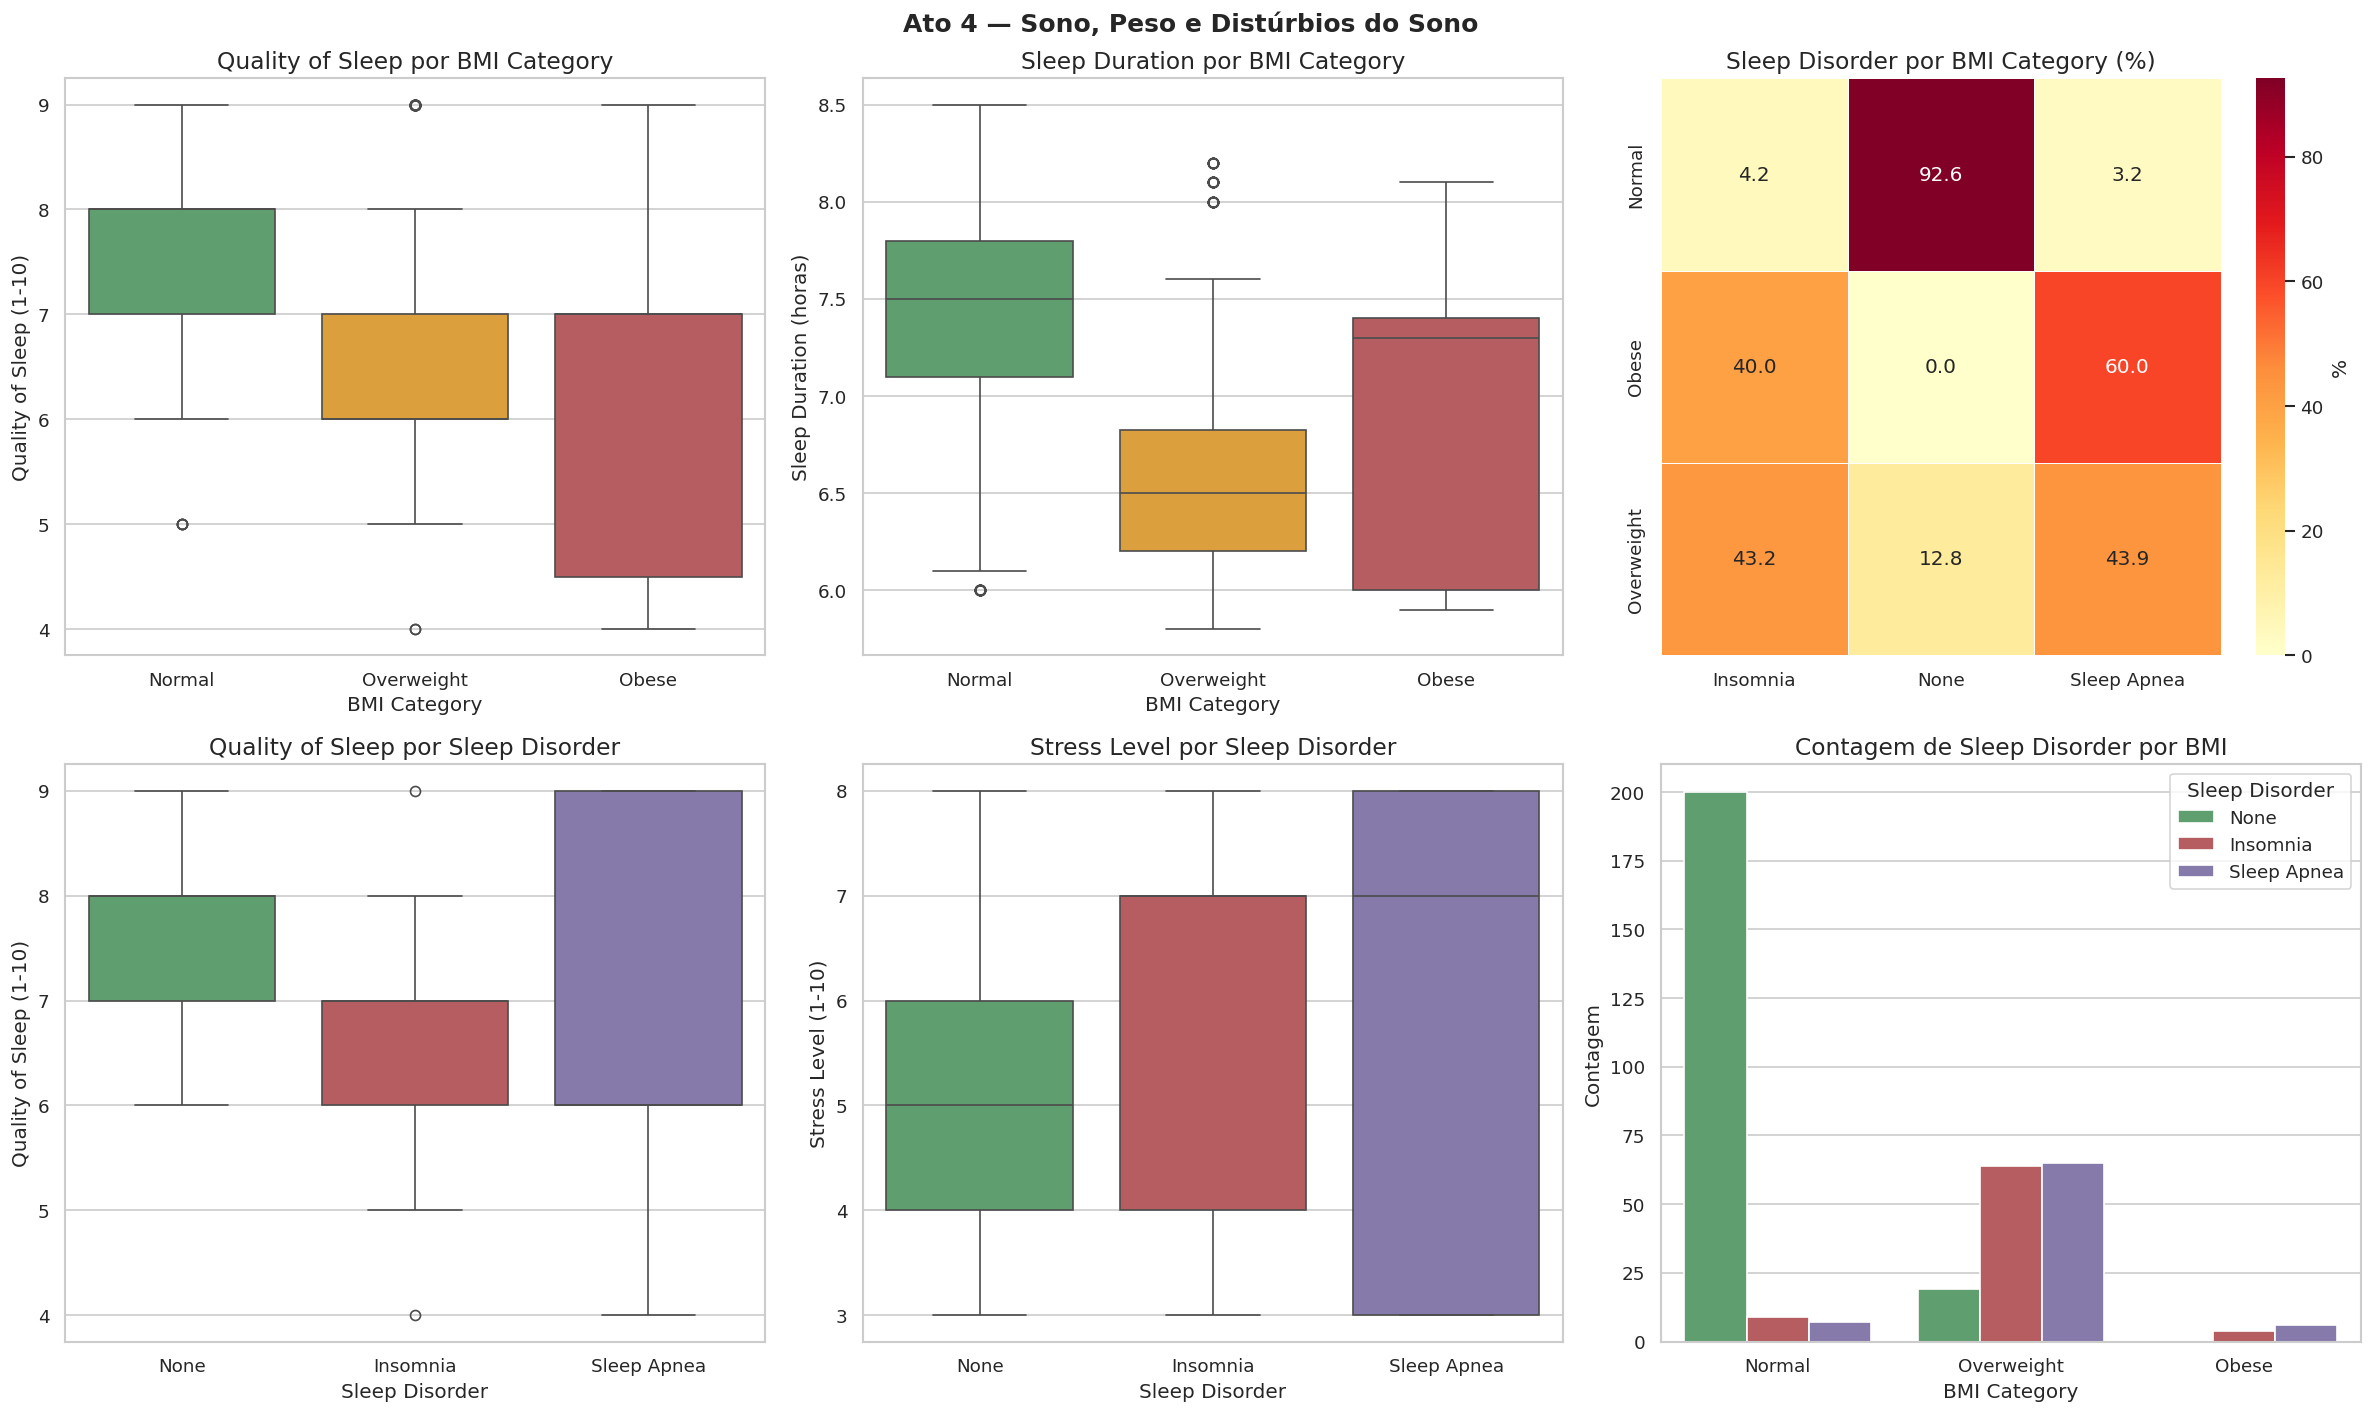

In [54]:
act4_sleep_vs_health(df)

**Validando seu conhecimento clínico com os dados**

O heatmap de Sleep Disorder por BMI é a tabela mais poderosa de toda a análise:

| BMI | None | Insomnia | Sleep Apnea |
|-----|------|----------|-------------|
| Normal | **92.6%** | 4.2% | 3.2% |
| Overweight | 12.8% | 43.2% | **43.9%** |
| Obese | 0.0% | 40.0% | **60.0%** |

A progressão é brutal e confirma exatamente o que você descreveu. Pessoa com peso normal tem 92.6% de chance de não ter distúrbio. Pessoa obesa tem 0% de chance de não ter — **100% tem insônia ou apneia**. E a apneia domina na obesidade (60%) exatamente pelo mecanismo hormonal e cardiovascular que você explicou.

---

**O que os boxplots adicionam**

**Quality of Sleep por BMI:** Normal tem IQR alto (6-8) com mediana 8 — mas com outliers baixos interessantes. Overweight tem mediana 6 e IQR comprimido. Obese tem mediana 7 mas IQR amplo (4.5-7) — alta variabilidade, alguns obesos dormem relativamente bem, outros muito mal.

**Sleep Duration por BMI:** Overweight tem a pior duração — mediana 6.5h com IQR estreito, consistentemente baixo. Obese tem IQR amplo — novamente alta variabilidade. Normal claramente dorme mais, mediana 7.5h.

**Stress por Disorder:** Insônia e Apneia têm estresse claramente mais alto que None. Apneia tem IQR enorme (3-8) — o estresse sozinho não explica a apneia, confirmando que o fator BMI/físico é o dominante na apneia, enquanto o estresse é mais associado à insônia.

---

**A descoberta mais sofisticada do Ato 4**

Olhando as métricas de Stress Level por BMI:

```
Normal:      mean=5.13, median=5.00
Overweight:  mean=5.73, median=7.00  ← mediana muito maior que a média
Obese:       mean=5.70, median=5.00
```

Overweight tem mediana de estresse 7 mas média 5.73 — **skew negativo forte**. Isso significa que a maioria das pessoas com sobrepeso tem estresse alto (7), mas uma minoria com estresse baixo puxa a média para baixo. Obese tem mediana 5 — o estresse não é o driver principal da obesidade nessa amostra, confirmando seu argumento hormonal/físico.

---

**Narrativa de fechamento do Ato 4:**


## Ato 4 — Conclusão

O peso é o preditor mais claro de distúrbios do sono nessa amostra.
Pessoas obesas têm 100% de prevalência de distúrbios, com apneia
dominando (60%) — consistente com mecanismos físicos e hormonais
conhecidos na literatura médica.

A insônia está mais associada ao sobrepeso e ao estresse elevado,
sugerindo um perfil diferente: enquanto a apneia tem base
física/hormonal, a insônia tem base psicológica/comportamental.

Importante: não podemos afirmar causalidade com dados transversais.
O ciclo pode ser bidirecional — obesidade causa apneia, mas apneia
e privação de sono também contribuem para ganho de peso via
desregulação hormonal (grelina/leptina).


---

Esse último ponto — a causalidade reversa via grelina e leptina — é exatamente o que fecha o ciclo que você identificou no início. Quer seguir para o **Ato 5 — O quadro completo**?

## Ato 5 — O Quadro Completo
A pergunta guia é:

`"Quando olhamos todas as variáveis juntas, o ciclo Lifestyle → Sono → Saúde se confirma?"`

In [55]:
def full_correlation_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Matriz de correlação de Spearman para todas as variáveis numéricas.

    Exclui Person ID por ser identificador sem significado estatístico.

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com matriz de correlação completa.
    """
    numeric_cols = [
        "Age",
        "Sleep Duration",
        "Quality of Sleep",
        "Physical Activity Level",
        "Stress Level",
        "Heart Rate",
        "Daily Steps",
    ]
    return df[numeric_cols].corr(method="spearman").round(3)


def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    """Codifica variáveis categóricas ordinais para inclusão na correlação.

    Encoding:
        BMI Category:   Normal=0, Overweight=1, Obese=2
        Sleep Disorder: None=0, Insomnia=1, Sleep Apnea=2

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com colunas adicionais codificadas.
    """
    d = df.copy()
    d["BMI_encoded"] = d["BMI Category"].map({
        "Normal": 0, "Overweight": 1, "Obese": 2
    })
    d["Disorder_encoded"] = d["Sleep Disorder"].map({
        "None": 0, "Insomnia": 1, "Sleep Apnea": 2
    })
    return d


def full_correlation_with_encoded(df: pd.DataFrame) -> pd.DataFrame:
    """Matriz de correlação completa incluindo variáveis categóricas codificadas.

    Args:
        df: DataFrame padronizado.

    Returns:
        pd.DataFrame com correlação de Spearman completa.
    """
    d = encode_categoricals(df)
    cols = [
        "Age",
        "Sleep Duration",
        "Quality of Sleep",
        "Physical Activity Level",
        "Stress Level",
        "Heart Rate",
        "Daily Steps",
        "BMI_encoded",
        "Disorder_encoded",
    ]
    return d[cols].corr(method="spearman").round(3)

In [56]:
def plot_full_heatmap(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Heatmap de correlação completa — todas as variáveis numéricas.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    corr = full_correlation_with_encoded(df)

    # Renomeia para labels mais legíveis
    labels = {
        "Age": "Age",
        "Sleep Duration": "Sleep Dur.",
        "Quality of Sleep": "Sleep Qual.",
        "Physical Activity Level": "Phys. Act.",
        "Stress Level": "Stress",
        "Heart Rate": "Heart Rate",
        "Daily Steps": "Daily Steps",
        "BMI_encoded": "BMI",
        "Disorder_encoded": "Disorder",
    }
    corr = corr.rename(index=labels, columns=labels)

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"shrink": 0.8}
    )
    ax.set_title("Correlação de Spearman — Quadro Completo", fontsize=13)
    ax.tick_params(axis="x", rotation=45)


def plot_cycle_summary(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Scatter de Stress Level vs Quality of Sleep colorido por BMI.

    Visualiza o ciclo completo Lifestyle → Sono → Saúde em um único gráfico.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    sns.scatterplot(
        data=df,
        x="Stress Level",
        y="Quality of Sleep",
        hue="BMI Category",
        style="Sleep Disorder",
        palette=_PAL_BMI,
        hue_order=_BMI_ORDER,
        alpha=0.7,
        s=80,
        ax=ax
    )
    ax.set_title(
        "Ciclo Completo: Stress → Qualidade do Sono → BMI\n"
        "(marcador = Sleep Disorder)",
        fontsize=11
    )
    ax.set_xlabel("Stress Level (1-10)")
    ax.set_ylabel("Quality of Sleep (1-10)")
    ax.legend(
        title="BMI / Disorder",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8
    )


def plot_bmi_distribution_by_disorder(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Proporção de BMI dentro de cada Sleep Disorder.

    Fecha o ciclo mostrando que distúrbios do sono concentram
    pessoas com BMI elevado.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    ct = pd.crosstab(
        df["Sleep Disorder"],
        df["BMI Category"],
        normalize="index"
    ) * 100

    ct = ct.reindex(index=_DIS_ORDER)[_BMI_ORDER]

    ct.plot(
        kind="bar",
        stacked=True,
        color=[_PAL_BMI[c] for c in _BMI_ORDER],
        ax=ax,
        edgecolor="white"
    )
    ax.set_title("Distribuição de BMI por Sleep Disorder (%)", fontsize=11)
    ax.set_xlabel("Sleep Disorder")
    ax.set_ylabel("%")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="BMI", bbox_to_anchor=(1.05, 1), loc="upper left")


def plot_stress_bmi_disorder(df: pd.DataFrame, ax: plt.Axes) -> None:
    """Boxplot de Stress Level por BMI colorido por Sleep Disorder.

    Args:
        df: DataFrame padronizado.
        ax: Eixo matplotlib.
    """
    sns.boxplot(
        data=df,
        x="BMI Category",
        y="Stress Level",
        hue="Sleep Disorder",
        order=_BMI_ORDER,
        hue_order=_DIS_ORDER,
        palette=_PAL_DISORDER,
        ax=ax
    )
    ax.set_title("Stress Level por BMI e Sleep Disorder", fontsize=11)
    ax.set_xlabel("BMI Category")
    ax.set_ylabel("Stress Level (1-10)")
    ax.legend(title="Sleep Disorder",
              bbox_to_anchor=(1.05, 1), loc="upper left")

In [57]:
def act5_full_picture(df: pd.DataFrame) -> None:
    """Ato 5 — O quadro completo.

    Consolida a análise dos 4 atos anteriores em uma visão integrada.
    Confirma o ciclo Lifestyle → Sono → Saúde através da correlação
    completa e visualizações que cruzam todas as dimensões.

    Args:
        df: DataFrame bruto.
    """
    d = _prep(df)
    _section("Ato 5 — O Quadro Completo")

    print("\n📊 Matriz de Correlação Completa")
    print(full_correlation_with_encoded(d).to_string())

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle(
        "Ato 5 — O Quadro Completo: Lifestyle → Sono → Saúde",
        fontsize=15, fontweight="bold"
    )

    plot_full_heatmap(d, axes[0, 0])
    plot_cycle_summary(d, axes[0, 1])
    plot_bmi_distribution_by_disorder(d, axes[1, 0])
    plot_stress_bmi_disorder(d, axes[1, 1])

    plt.tight_layout()
    plt.show()


  Ato 5 — O Quadro Completo

📊 Matriz de Correlação Completa
                          Age  Sleep Duration  Quality of Sleep  Physical Activity Level  Stress Level  Heart Rate  Daily Steps  BMI_encoded  Disorder_encoded
Age                      1.00            0.31              0.42                     0.14         -0.43       -0.25        -0.04         0.49              0.48
Sleep Duration           0.31            1.00              0.89                     0.21         -0.81       -0.61         0.01        -0.33             -0.25
Quality of Sleep         0.42            0.89              1.00                     0.18         -0.91       -0.73         0.02        -0.32             -0.24
Physical Activity Level  0.14            0.21              0.18                     1.00         -0.02        0.16         0.79         0.06              0.18
Stress Level            -0.43           -0.81             -0.91                    -0.02          1.00        0.82         0.17         0.14   

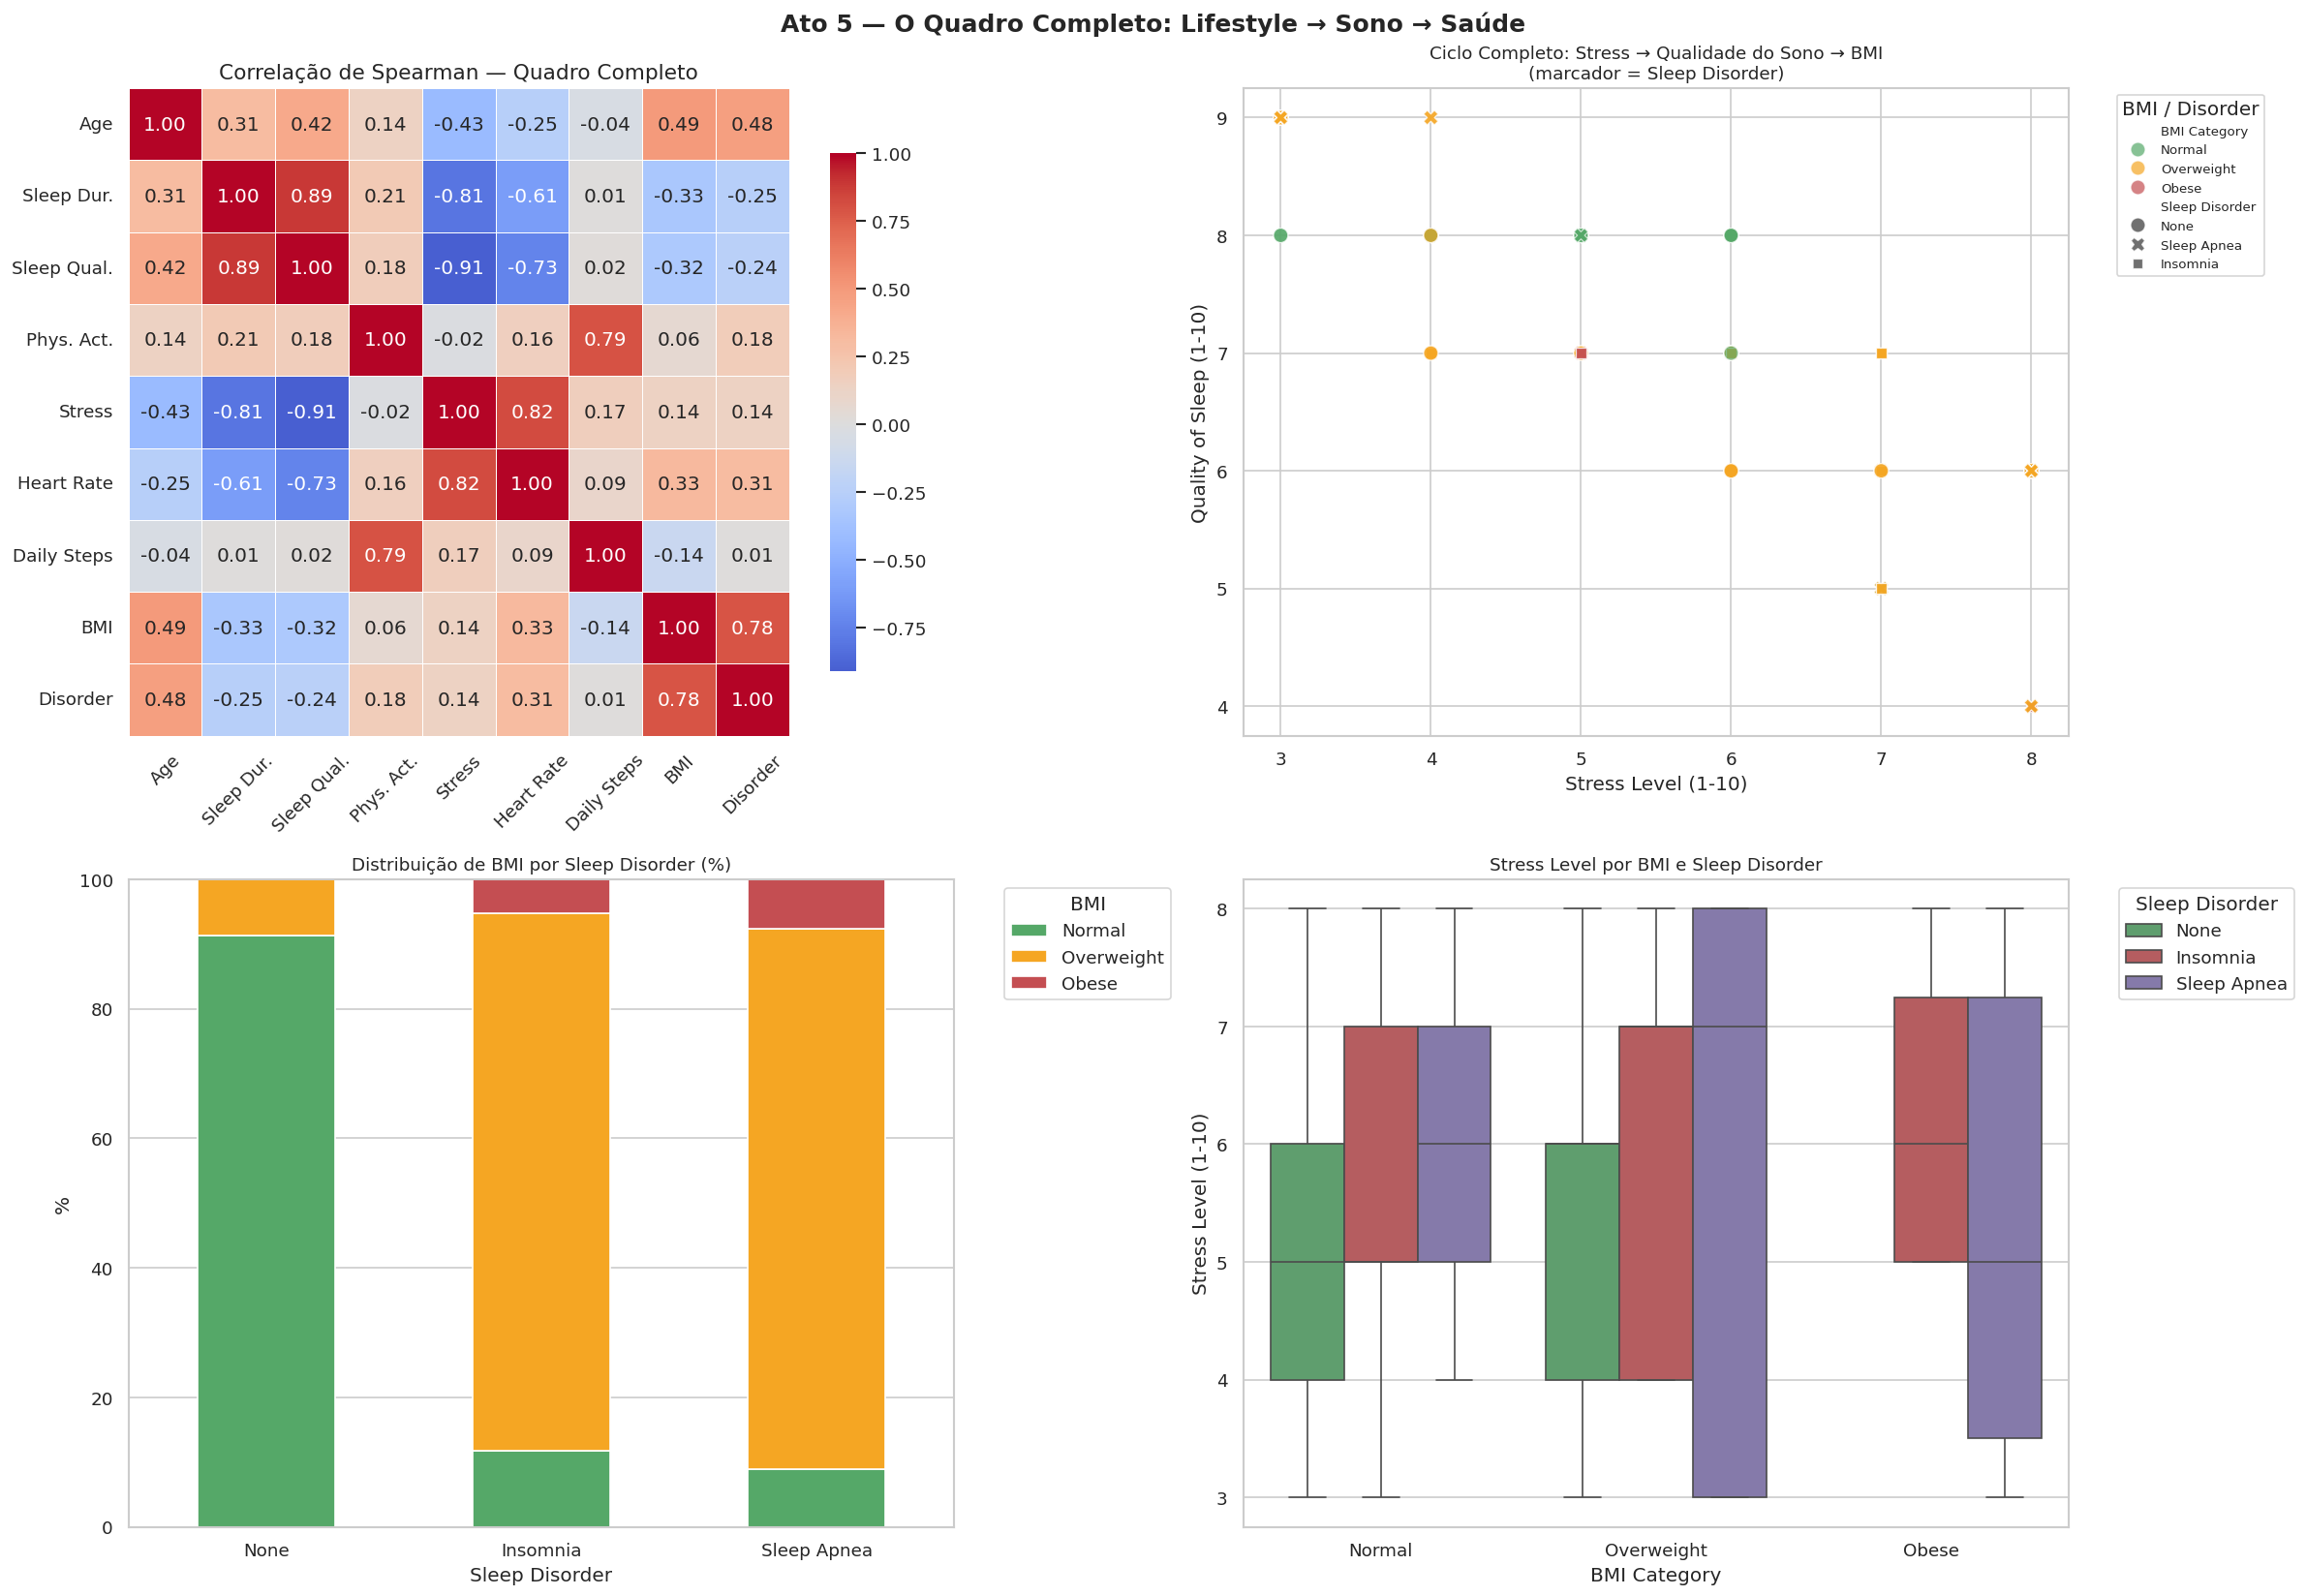

In [58]:
act5_full_picture(df)

**As descobertas mais importantes do heatmap completo**

**Stress Level é o hub central — confirmado:**
- Stress × Quality of Sleep: **-0.91** — a correlação mais forte de toda a matriz
- Stress × Sleep Duration: **-0.81**
- Stress × Heart Rate: **+0.82** — estresse alto = frequência cardíaca alta, fechando o ciclo cardiovascular que você mencionou

**Heart Rate — a surpresa do Ato 5:**
- Heart Rate × Quality of Sleep: **-0.73**
- Heart Rate × Sleep Duration: **-0.61**
- Heart Rate × Stress: **+0.82**

Frequência cardíaca elevada é um proxy do estresse fisiológico — não é causa direta do sono ruim, mas é o sinal físico de que o organismo está sob pressão. Isso conecta diretamente com o mecanismo da apneia que você explicou.

**Age — correlação esquecida nos atos anteriores:**
- Age × BMI: **+0.49**
- Age × Disorder: **+0.48**
- Age × Quality of Sleep: **+0.42**

Mais velho = maior BMI e maior prevalência de distúrbios. Isso retroalimenta o viés do Ato 1 — mulheres mais velhas (Nurses) concentram mais distúrbios não só pela ocupação, mas pela idade em si.

**BMI × Disorder: +0.78** — a relação mais forte fora do cluster Stress/Sono. Confirma o Ato 4 numericamente.

---

**O ciclo completo confirmado pelos dados:**

```
Age ──────────────────────────────────────────┐
                                              ↓
Occupation → Stress Level → Heart Rate → BMI → Sleep Disorder
                    ↓              ↓
             Sleep Duration   Quality of Sleep
```

## Ato 5 — Conclusão: O Quadro Completo

### O ciclo Lifestyle → Sono → Saúde se confirma

O estresse emerge como o hub central da análise — com as
correlações mais fortes da matriz (-0.91 com Quality of Sleep,
-0.81 com Sleep Duration). Não é o volume de atividade física
ou a quantidade de passos que determina a qualidade do sono,
mas o nível de pressão psicológica e fisiológica ao qual a
pessoa está submetida.

A frequência cardíaca elevada funciona como proxy fisiológico
do estresse — sua correlação de +0.82 com Stress Level e
-0.73 com Quality of Sleep fecha o ciclo cardiovascular.

A idade amplifica todos os efeitos: pessoas mais velhas têm
maior BMI (+0.49), maior prevalência de distúrbios (+0.48)
e — surpreendentemente — melhor qualidade de sono (+0.42),
o que sugere que com a idade vem também uma melhor gestão
do estresse ou rotinas mais estáveis.

BMI e Sleep Disorder caminham juntos (+0.78), com a apneia
concentrada em obesos e a insônia distribuída entre
sobreweight e estresse elevado — perfis clínicos distintos
que exigem intervenções diferentes.

### Limitações
- Dados transversais: associação, não causalidade
- Amostra enviesada: 55% profissionais de saúde e engenharia
- Variáveis subjetivas: Quality of Sleep e Stress auto-reportados
- Ausência de dados longitudinais impede investigar o ciclo
  bidirecional sono → obesidade → sono

---

**Hub**

Vem da ideia de um ponto central de conexão — como um hub de aeroporto onde vários voos convergem.

Na análise de dados, uma variável é chamada de hub quando ela se correlaciona fortemente com muitas outras variáveis ao mesmo tempo. No nosso caso:

Stress Level tem correlação forte com Quality of Sleep (-0.91), Sleep Duration (-0.81), Heart Rate (+0.82) e Age (-0.43). Ou seja, quase tudo na matriz passa pelo estresse — ele não é apenas mais uma variável, é o ponto central que conecta lifestyle, sono e saúde.

---

**Proxy**

Proxy significa substituto ou representante indireto. Usamos uma variável proxy quando não conseguimos medir diretamente o que queremos, mas temos outra variável que se comporta de forma similar.

No nosso caso, não medimos diretamente o estresse fisiológico do organismo — medimos o Stress Level por auto-relato, que é subjetivo. Mas a Heart Rate é uma medida objetiva do corpo — quando o coração bate mais rápido em repouso, é um sinal físico de que o organismo está sob pressão. Por isso dissemos que Heart Rate é um proxy do estresse fisiológico — ela não é o estresse, mas representa indiretamente o mesmo fenômeno pelo ângulo físico.

---

**Resumindo com uma analogia:**

> Proxy é como medir a temperatura do asfalto para inferir a temperatura do ar — você não está medindo diretamente o que quer, mas a variável escolhida se comporta de forma suficientemente similar para ser útil.

Ficou claro? Podemos seguir para o Must Know?

**Must Know — Estatística Descritiva para Data Scientists**

Vou organizar pelo que realmente aparece em provas e entrevistas sênior, conectado com o que vivemos na análise.

---

**1. Tipos de variáveis — e as armadilhas**

O que cai na prova não é a definição — é a armadilha:

```markdown
| Armadilha | Exemplo do nosso dataset |
|-----------|--------------------------|
| Variável numérica que é ordinal | Quality of Sleep — int64 no pandas, mas ordinal na prática |
| Variável categórica que parece ordinal | BMI Category — tem ordem implícita mas não é escala numérica |
| Identificador tratado como numérico | Person ID — int64 mas não entra em nenhuma análise |
| Variável contínua armazenada como string | Blood Pressure — "120/80" precisa parsing |
```

**A resposta sênior:** *"o dtype técnico é o ponto de partida, a classificação estatística exige interpretação do domínio."*

---

**2. Medidas de centro — quando usar cada uma**

```markdown
| Medida | Usar quando | Evitar quando |
|--------|-------------|---------------|
| Média | Distribuição simétrica, sem outliers | Skew forte ou outliers relevantes |
| Mediana | Distribuição assimétrica | Quando se quer capturar o efeito dos extremos |
| Moda | Variáveis discretas e ordinais | Distribuições contínuas multimodais |
```

**O que cai na prova:** *"qual medida de centro você usaria para Stress Level e por quê?"* — resposta: mediana, porque é ordinal e a distribuição tem skew positivo.

---

**3. Skewness — a relação Mean/Median/Mode**

```markdown
Skew positivo  → Mean > Median > Mode → cauda à direita → massa à esquerda
Skew negativo  → Mean < Median < Mode → cauda à esquerda → massa à direita
Simétrico      → Mean ≈ Median ≈ Mode → distribuição normal
```

**A implicação prática** — a média é sempre puxada na direção da cauda. Quando há skew, a mediana representa melhor o comportamento típico.

**Do nosso dataset:**
- Physical Activity: skew negativo — maioria acima da média, minoria sedentária puxa para baixo
- Stress Level: skew positivo — minoria com estresse muito alto puxa a média acima da mediana
- Daily Steps: skew negativo — maioria caminha mais do que a média sugere

---

**4. Medidas de dispersão — além do desvio padrão**

```markdown
| Medida | O que revela | Quando é superior |
|--------|-------------|-------------------|
| Std | Dispersão geral | Distribuição aproximadamente normal |
| IQR | Dispersão dos 50% centrais | Distribuições assimétricas ou com outliers |
| CV | Dispersão relativa (%) | Comparar variáveis em escalas diferentes |
| Range | Amplitude total | Nunca usar sozinho — dominado por extremos |
```

**A resposta sênior para a prova:** *"std e IQR são complementares — std captura a dispersão geral incluindo outliers, IQR é robusto a eles. Para Stress Level com skew positivo, o IQR é mais representativo."*

---

**5. Outliers — detectar e interpretar**

Dois métodos principais:

**Via IQR:**
```
Limite inferior: Q1 - 1.5 × IQR
Limite superior: Q3 + 1.5 × IQR
```

**Via Z-score:**
```
Z = (x - mean) / std
|Z| > 3 → outlier
```

**A armadilha da prova:** *"encontrou outliers, o que você faz?"* — a resposta errada é "remover". A resposta sênior é: *"investigar o contexto. No nosso dataset, outliers de Heart Rate concentram-se em pacientes com Sleep Apnea — fazem sentido clínico e não devem ser removidos."*

---

**6. Correlação — Pearson vs Spearman**

```markdown
| | Pearson | Spearman |
|--|---------|----------|
| Assume | Distribuição normal, relação linear | Não assume normalidade |
| Mede | Correlação linear | Correlação monotônica |
| Usar quando | Variáveis contínuas normais | Ordinais ou distribuições assimétricas |
| Sensível a outliers | Sim | Não |
```

**Por que usamos Spearman na nossa análise:** Stress Level e Quality of Sleep são ordinais — não assumimos que a diferença entre 3 e 4 é igual à diferença entre 7 e 8. Spearman respeita isso.

**A frase que fecha qualquer pergunta sobre correlação:**
> *"Correlação mede associação, não causalidade. A correlação de -0.91 entre Stress e Quality of Sleep não prova que estresse causa sono ruim — apenas que as duas variáveis se movem juntas de forma consistente nessa amostra."*

---

**7. População vs Amostra — o detalhe técnico**

```markdown
| | População | Amostra |
|--|-----------|---------|
| Desvio padrão | divide por n | divide por n-1 (correção de Bessel) |
| pandas std() | ddof=0 | ddof=1 (padrão) |
| Objetivo | descrever | inferir |
```

**O que cai na prova:** *"por que dividimos por n-1 na amostra?"* — para corrigir o viés da estimativa. Com n-1 a variância amostral é um estimador não-viesado da variância populacional.

---

**8. O que a análise descritiva NÃO pode afirmar**

Esse é o ponto que mais diferencia sênior de júnior:

```markdown
❌ "Estresse causa sono ruim" → correlação não é causalidade
❌ "Obesos têm apneia porque dormem mal" → pode ser o inverso
❌ "Enfermeiras dormem mal por causa do estresse" → confounding variable — pode ser o turno noturno
❌ "Esses resultados valem para a população geral" → amostra enviesada para profissionais de saúde
✅ "Nessa amostra, observamos associação forte entre estresse e qualidade do sono"
✅ "Os dados são consistentes com a hipótese de que BMI influencia Sleep Apnea"
```

---

**Resumindo — o que um sênior sabe que um júnior não sabe:**

O júnior calcula as métricas. O sênior sabe escolher a métrica certa, interpretar o que ela revela, identificar os limites do que pode concluir, e conectar tudo em uma narrativa coerente com o domínio do problema.

---

Quer simular algumas questões no estilo da prova agora com base nesses must knows?

In [64]:
def plot_boxplot_histogram(
    df: pd.DataFrame,
    col: str,
    color: str = "#4c72b0"
) -> None:
    """Plota boxplot (acima) e histograma (abaixo) alinhados para uma variável.

    A disposição vertical permite correlacionar visualmente:
    - Q1, mediana, Q3 e outliers do boxplot
    - com a forma da distribuição e densidade do histograma

    Args:
        df: DataFrame padronizado.
        col: Nome da coluna numérica a ser plotada.
        color: Cor base dos gráficos. Default: azul.
    """
    mean   = df[col].mean()
    median = df[col].median()
    q1     = df[col].quantile(0.25)
    q3     = df[col].quantile(0.75)
    iqr    = q3 - q1

    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05},
        
    )

    fig.suptitle(
        f"Distribuição de {col}",
        fontsize=14, fontweight="bold", y=1.01
    )

    # ── Boxplot ───────────────────────────────────────────────────────────────
    sns.boxplot(
        x=df[col],
        ax=ax_box,
        color=color,
        width=0.4,
        linewidth=1.5,
        flierprops={"marker": "o", "markerfacecolor": "#c44e52", "markersize": 6}
    )

    # Anotações no boxplot
    for value, label, va in [
        (q1,     f"Q1={q1:.0f}",         "bottom"),
        (median, f"Md={median:.0f}",      "bottom"),
        (q3,     f"Q3={q3:.0f}",          "bottom"),
    ]:
        ax_box.axvline(value, color="#333333", linewidth=1, linestyle=":")
        ax_box.text(
            value, 0.5, label,
            transform=ax_box.get_xaxis_transform(),
            ha="center", va=va, fontsize=9, color="#333333"
        )

    ax_box.axvline(mean, color="#e05c00", linewidth=1.8,
                   linestyle="--", label=f"Mean={mean:.0f}")
    ax_box.legend(fontsize=9, loc="upper right")
    ax_box.set(ylabel="", yticks=[])
    sns.despine(ax=ax_box, left=True)

    # ── Histograma ────────────────────────────────────────────────────────────
    sns.histplot(
        data=df, x=col,
        kde=True,
        color=color,
        alpha=0.6,
        ax=ax_hist
    )

    # Linhas verticais alinhadas com o boxplot
    ax_hist.axvline(mean,   color="#e05c00", linewidth=1.8,
                    linestyle="--", label=f"Mean = {mean:.0f}")
    ax_hist.axvline(median, color="#333333", linewidth=1.8,
                    linestyle=":",  label=f"Median = {median:.0f}")
    ax_hist.axvline(q1, color="#aaaaaa", linewidth=1.2,
                    linestyle=":", label=f"Q1 = {q1:.0f}")
    ax_hist.axvline(q3, color="#aaaaaa", linewidth=1.2,
                    linestyle=":", label=f"Q3 = {q3:.0f}")

    # Área do IQR sombreada
    ax_hist.axvspan(q1, q3, alpha=0.10, color=color, label=f"IQR = {iqr:.0f}")

    ax_hist.set_xlabel(col, fontsize=11)
    ax_hist.set_ylabel("Contagem", fontsize=11)
    ax_hist.legend(fontsize=9, loc="upper right")
    sns.despine(ax=ax_hist)

    # depois do fig existir, e no lugar do plt.tight_layout()
    fig.subplots_adjust(hspace=0.05)
    plt.savefig(
    f"{col.replace(' ', '_')}_boxplot_histogram.png",
    dpi=150, bbox_inches="tight"
)
    plt.show()

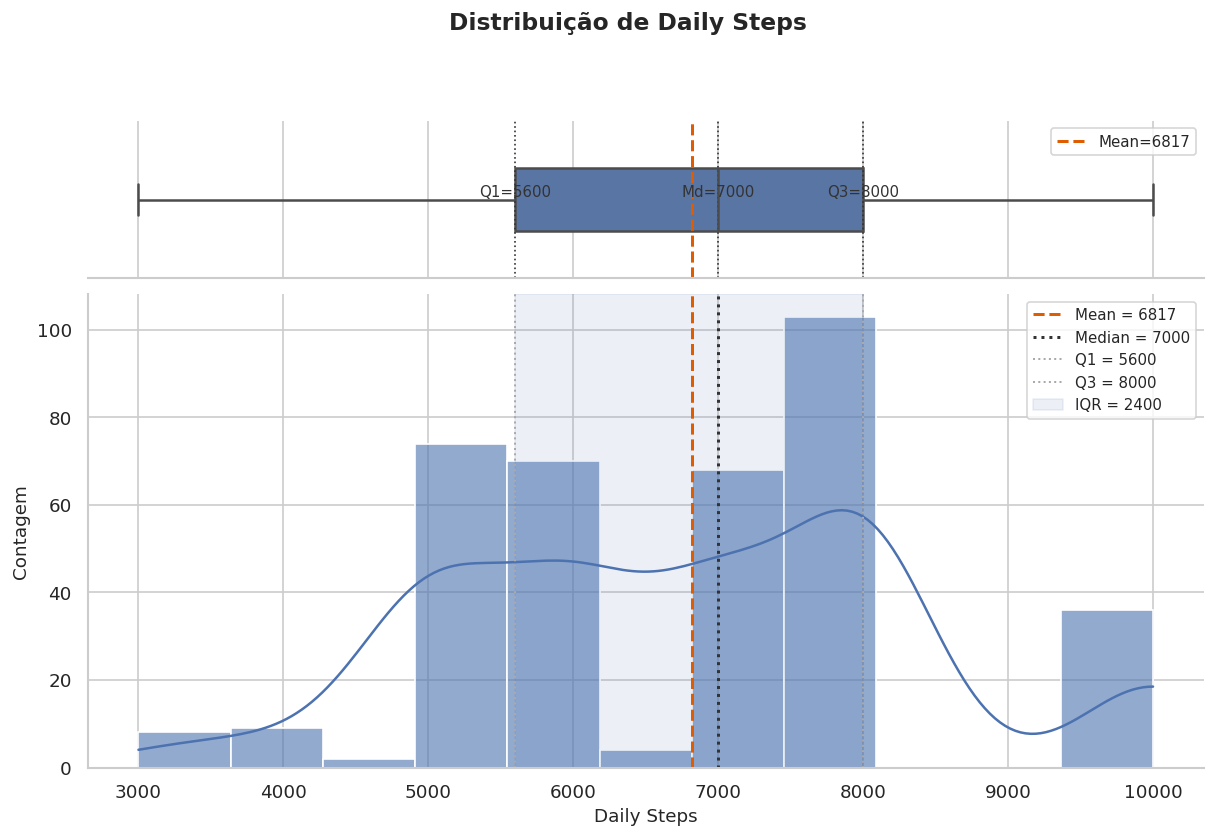

In [65]:
d = _prep(df)
plot_boxplot_histogram(d, "Daily Steps")

In [68]:
d.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='str')

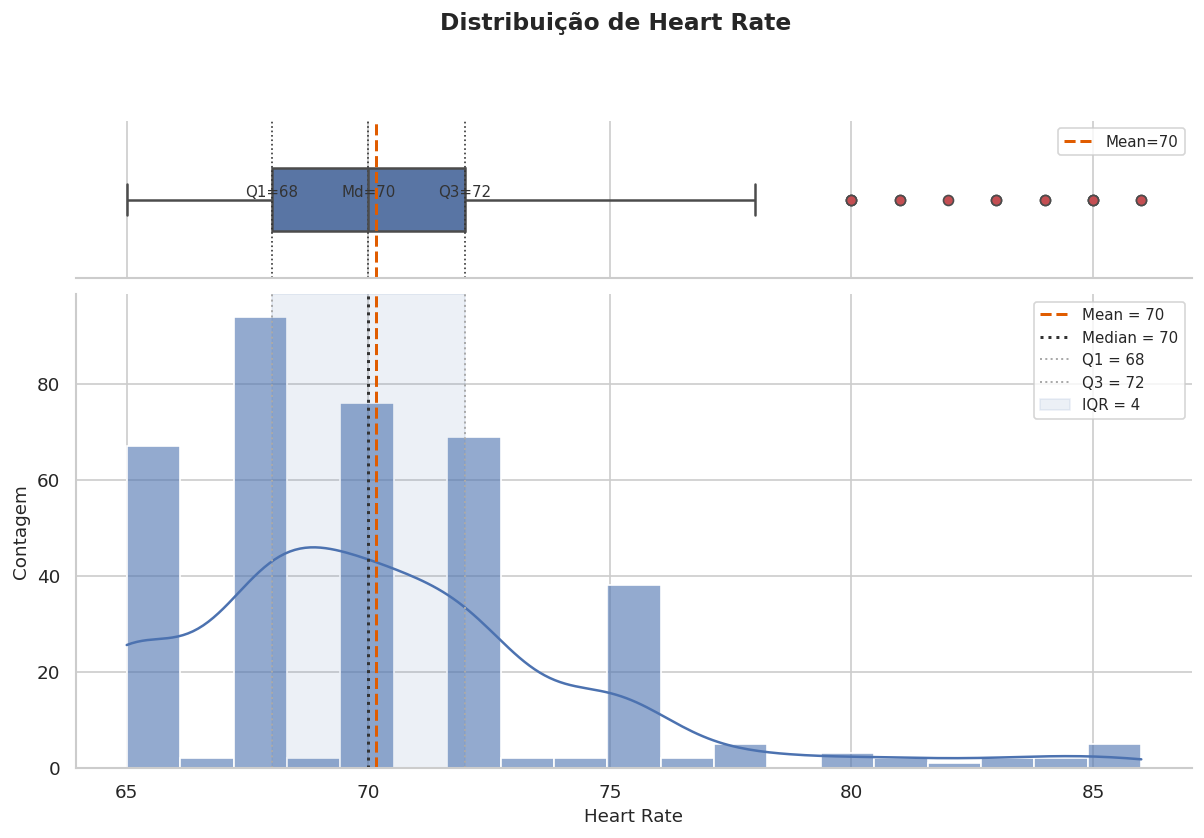

In [69]:
plot_boxplot_histogram(d, "Heart Rate")

### Steph Curry Shot Dataset

| Dataset Columns | Description |
| --- | --- |
| **top** | The vertical position on the court where the shot was taken. |
| **left** | The horizontal position on the court where the shot was taken. |
| **date** | The date when the shot was taken (e.g., Oct 18, 2022). |
| **qtr** | The quarter of the attempt (e.g., "1st Qtr", "2nd Qtr"). |
| **time_remaining** | Time remaining in the quarter (e.g., 09:26). |
| **result** | Success of the shot: **TRUE** (made) or **FALSE** (missed). |
| **shot_type** | Type of shot: **2** (two-pointer) or **3** (three-pointer). |
| **distance_ft** | Distance in feet from the hoop to the shot location. |
| **lead** | **TRUE** if Curry's team was leading, **FALSE** otherwise. |
| **player_team_score** | Steph Curry's team's score at the time of the shot. |
| **opponent_team_score** | The opposing team's score at the time of the shot. |
| **opponent** | Abbreviation for the opposing team (e.g., LAL). |
| **team** | Abbreviation for Steph Curry's team (e.g., GSW). |
| **season** | The season year (e.g., 2023). |
| **color** | Color code (e.g., "red" or "green") for visual shot mapping. |